<a href="https://colab.research.google.com/github/ludo9fox123-glitch/machine-learning/blob/main/ML_assignment_1_group_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 — Unsupervised Learning  


- Méan Ludovic
- Christian Dorado
- José Pablo Soriano
- Johanna Albers
- Noa Janer


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

possible_paths = [
    "/content/drive/MyDrive/ML_Group10",
    "/content/drive/Shareddrives/ML_Group10",
    "/content/drive/MyDrive/ML/ML_Group10"
]

BASE_PATH = None
for path in possible_paths:
    if os.path.exists(path):
        BASE_PATH = path
        break

if BASE_PATH is None:
    raise FileNotFoundError("Project folder not found. Add it to My Drive.")

DATA_PATH = f"{BASE_PATH}/data"

print("Using data path:", DATA_PATH)
print("Files:", os.listdir(DATA_PATH))

Mounted at /content/drive
Using data path: /content/drive/MyDrive/ML/ML_Group10/data
Files: ['processed.cleveland.data']


In [ ]:
# =========================
# 0. Import libraries
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    recall_score, f1_score, confusion_matrix,
    adjusted_rand_score
)



# Task 1 — Data Loading & Exploration

We need to understand the dataset:

- what variables are present?
- are there missing values?
- do some variables seem abnormal?
- are variables correlated?
- which variables are numerical and which are categorical?


## 1. Loading the dataset

The raw file `processed.cleveland.data` does not contain column names.  
We therefore add them manually based on the dataset documentation.


In [ ]:
# Column names based on the dataset documentation
columns = [
    'age',        # patient's age
    'sex',        # sex (1 = male, 0 = female)
    'cp',         # chest pain type
    'trestbps',   # resting blood pressure
    'chol',       # serum cholesterol
    'fbs',        # fasting blood sugar > 120 mg/dl
    'restecg',    # resting electrocardiographic results
    'thalach',    # maximum heart rate achieved
    'exang',      # exercise-induced angina
    'oldpeak',    # ST depression induced by exercise
    'slope',      # slope of the peak exercise ST segment
    'ca',         # number of major vessels colored by fluoroscopy
    'thal',       # thalassemia
    'target'      # diagnosis of heart disease
]

# Load the raw file
file_path = f"{DATA_PATH}/processed.cleveland.data"
df = pd.read_csv(file_path, names=columns)

# Display the first rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Dataset overview

Here, we check:

- the **size** of the dataset,
- the **types of variables**,
- the **descriptive statistics**.

We identify if some columns were incorrectly read and provides an initial overview of value ranges.


In [ ]:
# Dataset shape: (number of rows, number of columns)
df.shape

(303, 14)

In [ ]:
# Variable types before cleaning
df.dtypes

,0
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


In [ ]:
# Descriptive statistics
# include='all' also shows some information for non-numeric columns
df.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303,303,303.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,4,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.0,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,176,166,NaN
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,NaN,NaN,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,NaN,NaN,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,NaN,NaN,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,NaN,NaN,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,NaN,NaN,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,NaN,NaN,2.000000


## 3. Handling missing values

### What we do
1. Replace `"?"` with `NaN` (In this dataset, some missing values may be coded with the symbol **"?"**)
2. Convert columns to numeric format
3. Check the number of missing values
4. Replace missing values with the **median**

### Why the median?
In a medical dataset, some variables may contain extreme values (outliers).  
The **median** is more robust than the mean in such cases.


In [ ]:
# Replace '?' with actual missing values recognized by pandas
df.replace("?", np.nan, inplace=True)

# Convert all columns to numeric
# Some columns were read as text because of the '?'
df = df.apply(pd.to_numeric)

# Number of missing values per column
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
# Median imputation
# This makes it possible to keep all rows in the dataset
df = df.fillna(df.median())

# Check: there should no longer be any missing values
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


## 4. Variable distributions

### plots?
- **Histograms** show the shape of the distribution
- **Boxplots** help identify **outliers**

This is useful to see:
- which variables are mostly continuous,
- which variables are categorical but encoded as numbers,
- which variables have very different scales.


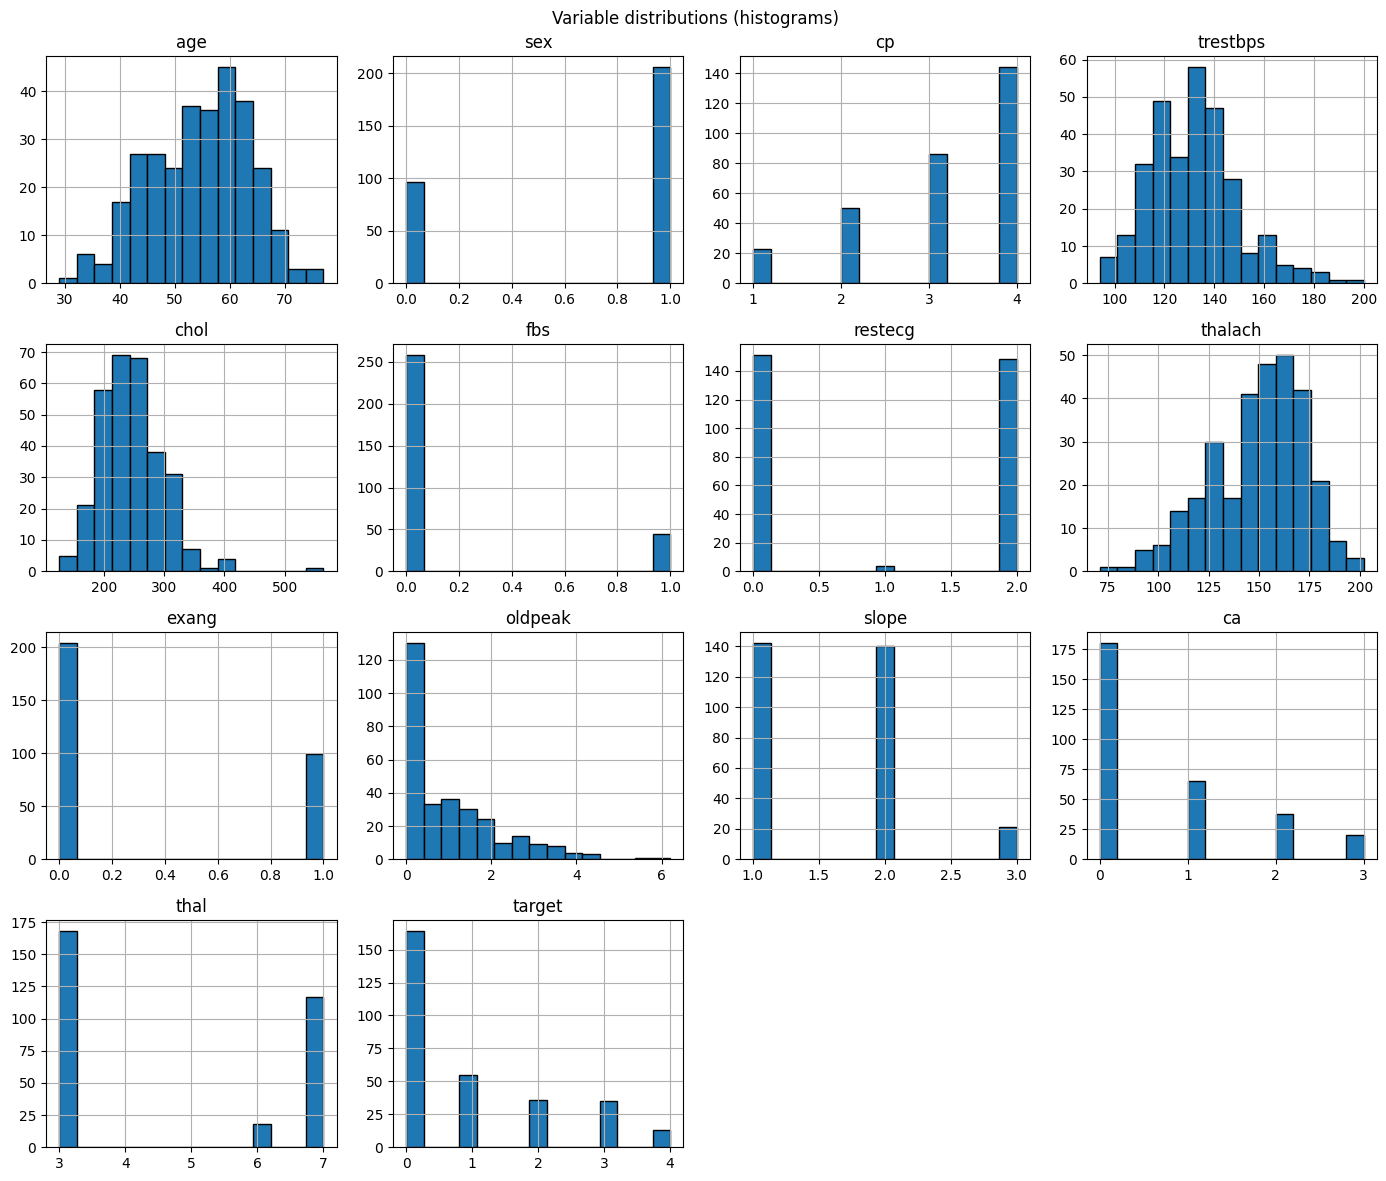

In [ ]:
# Histograms for all variables
df.hist(figsize=(14, 12), bins=15, edgecolor='black')
plt.suptitle("Variable distributions (histograms)")
plt.tight_layout()
plt.show()

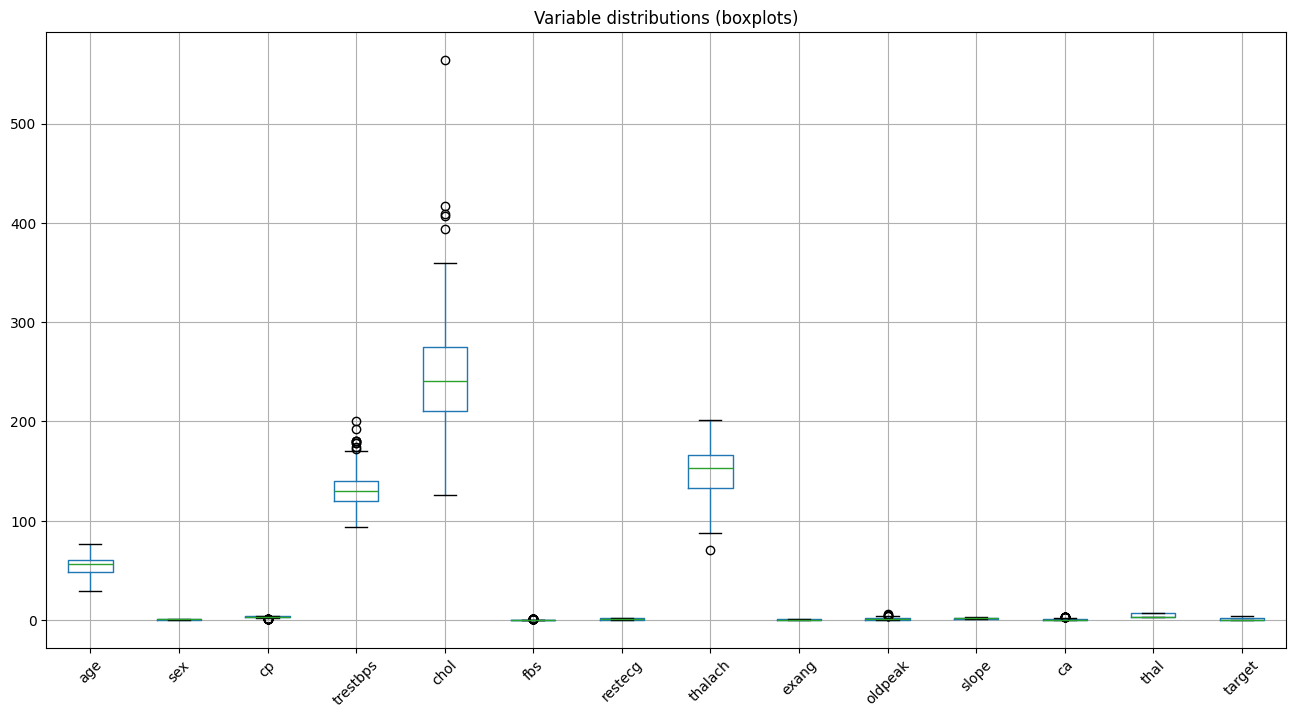

In [ ]:
# Boxplots for all variables
plt.figure(figsize=(16, 8))
df.boxplot(rot=45)
plt.title("Variable distributions (boxplots)")
plt.show()

### Interpretation

At this stage, we can already notice:

- some variables are **continuous**: `age`, `trestbps`, `chol`, `thalach`, `oldpeak`.
- one variable is **ordinal**: `ca`.
- others are **nominal (multi-class categorical)**: `cp`, `restecg`, `slope`, `thal`.
- others are **binary categorical**: `sex`, `fbs`, `exang`.
- some variables are not on the same scale at all, which already suggests that **scaling** will be necessary in Task 2.


## 5. Correlations between variables

The correlation heatmap helps identify whether two variables tend to vary together.

- a correlation close to **+1** means that two variables increase together,
- a correlation close to **-1** means that when one variable increases, the other tends to decrease,
- a correlation close to **0** means that there is no strong linear relationship.

Overall, the dataset shows mostly **moderate correlations**, rather than extremely high ones.  
This suggests that the variables are related in some cases, but there is no strong evidence of severe multicollinearity.

The strongest relationship appears between **oldpeak** and **slope**, with a correlation of about **-0.58**.  
This is a moderate negative correlation: patients with higher ST depression tend to have lower values of slope.

Since the strongest correlations remain well below **0.8**, the relationships between variables are not considered problematic.


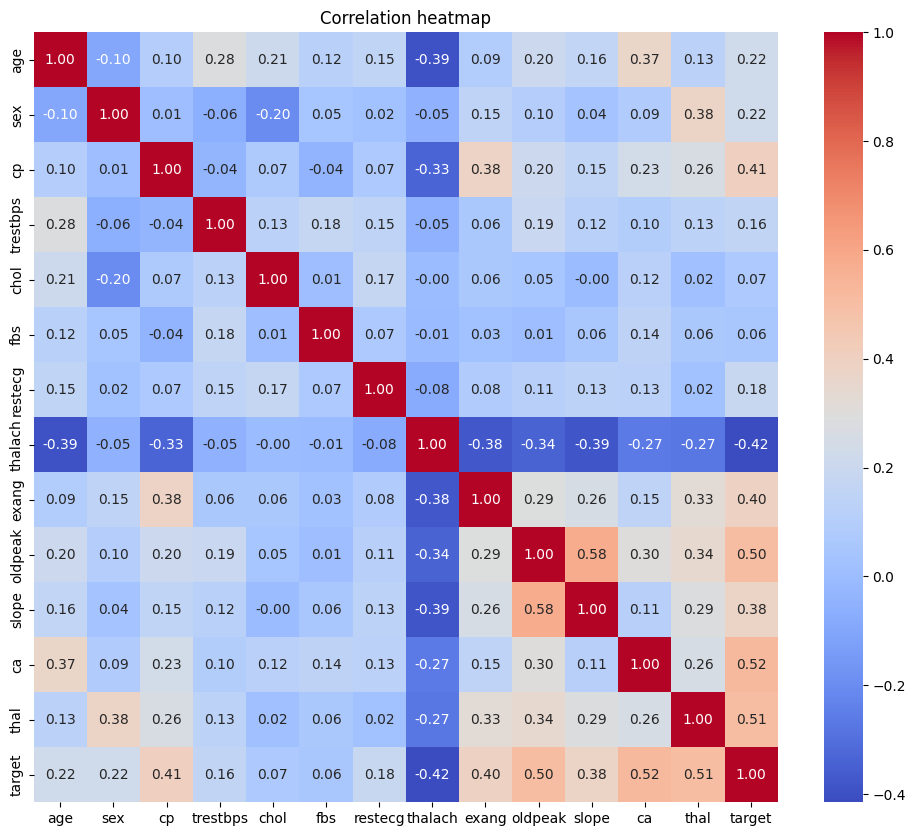

In [ ]:
# Correlation matrix
correlation_matrix = df.corr()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

### Interpretation
These are mostly moderate correlations, not extremely high. Between features themselves, the highest is between oldpeak and slope (~0.58), This is moderate but not alarming. Correlations higher than 0.7 or 0.8 are usually considered too high because they might bring a risk of multicollinearity.

## 6. Separation of the target variable

The **target** variable must remain separate and should not be used during clustering.

### Why?
Clustering is an **unsupervised** method:
therefore, we must not use the ground truth to form groups.

The target will be used **later**, only:
- in the **supervised feature selection** section allowed by the assignment,
- then in the final evaluation.


In [ ]:
# Standard split between explanatory variables and target
X = df.drop("target", axis=1).copy()
y_raw = df["target"].copy()

# Display dimensions
X.shape, y_raw.shape

((303, 13), (303,))

# Task 2 — Preprocessing & Feature Engineering

## Link with Task 1
Task 1 showed us two essential things:

1. Some variables are **categorical but encoded as numbers**  
   → they must be encoded properly

2. Variables are on **different scales**  
   → they must be standardized before PCA and clustering

In this Task 2, we therefore transform the dataset properly before applying clustering methods.


## 1. Preparing the target for Task 2

According to the assignment, the target variable is defined as follows:

- 0 indicates no disease

- 1 to 4 indicate the presence of disease

We create a binary version of the target at this stage, but it will be used only during supervised feature selection, as allowed by the assignment.


In [ ]:
# Binarisation de la cible :
# 0 = no disease
# 1 = disease present (values 1 to 4)
y = (y_raw > 0).astype(int)

y.value_counts()

,count
target,
0,164
1,139


In [ ]:
y.shape

(303,)

## 2. Encoding categorical variables

### We know that

- machine learning does not understand categories directly,
- **label encoding** creates an artificial order,
- **one-hot encoding** avoids that artificial order.

We therefore apply **One-Hot Encoding** to categorical variables with multiple categories:

- `cp`
- `restecg`
- `slope`
- `thal`

We keep:
- the already binary variables: `sex`, `fbs`, `exang`
- the continuous variables: `age`, `trestbps`, `chol`, `thalach`, `oldpeak`
- We keep `ca` as a numeric discrete feature because it represents a count-like ordered variable.

In [ ]:
# Copy of the features for Task 2
X_task2 = X.copy()

# Variables to encode with one-hot
categorical_cols = ["cp", "restecg", "slope", "thal"]

# One-Hot Encoding
# drop_first=True avoids creating redundant columns
X_encoded = pd.get_dummies(X_task2, columns=categorical_cols, drop_first=True)

# Preview of the new dataset
X_encoded.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,cp_2.0,cp_3.0,cp_4.0,restecg_1.0,restecg_2.0,slope_2.0,slope_3.0,thal_6.0,thal_7.0
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,False,False,False,False,True,False,True,True,False
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,False,False,True,False,True,True,False,False,False
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,False,False,True,False,True,True,False,False,True
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,False,True,False,False,False,False,True,False,False
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,True,False,False,False,True,False,False,False,False


In [ ]:
# Check the number of variables after encoding
X_encoded.shape

(303, 18)

## 3. Standardizing variables

We apply feature scaling to ensure that all variables are on a comparable scale.

We choose **standardization** using `StandardScaler`, which transforms each feature to have a mean of 0 and a standard deviation of 1.

This is important because:

- the variables are measured on different scales (e.g., age vs cholesterol),
- PCA is based on variance and would be dominated by features with larger values,
- clustering algorithms such as K-Means rely on distance metrics and are highly sensitive to scale.

Standardization ensures that each feature contributes equally to the analysis.


In [ ]:
# Standardization of variables
# Each variable is centered (mean 0) and scaled (standard deviation 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Put the result back into a DataFrame to keep column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X_encoded.columns)

X_scaled_df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,cp_2.0,cp_3.0,cp_4.0,restecg_1.0,restecg_2.0,slope_2.0,slope_3.0,thal_6.0,thal_7.0
0,0.948726,0.686202,0.757525,-0.264900,2.394438,0.017197,-0.696631,1.087338,-0.711131,-0.444554,-0.629534,-0.951662,-0.115663,1.023375,-0.926766,3.664502,3.979112,-0.793116
1,1.392002,0.686202,1.611220,0.760415,-0.417635,-1.821905,1.435481,0.397182,2.504881,-0.444554,-0.629534,1.050793,-0.115663,1.023375,1.079021,-0.272888,-0.251312,-0.793116
2,1.392002,0.686202,-0.665300,-0.342283,-0.417635,-0.902354,1.435481,1.346147,1.432877,-0.444554,-0.629534,1.050793,-0.115663,1.023375,1.079021,-0.272888,-0.251312,1.260850
3,-1.932564,0.686202,-0.096170,0.063974,-0.417635,1.637359,-0.696631,2.122573,-0.711131,-0.444554,1.588476,-0.951662,-0.115663,-0.977158,-0.926766,3.664502,-0.251312,-0.793116
4,-1.489288,-1.457296,-0.096170,-0.825922,-0.417635,0.980537,-0.696631,0.310912,-0.711131,2.249444,-0.629534,-0.951662,-0.115663,1.023375,-0.926766,-0.272888,-0.251312,-0.793116


In [ ]:
X_scaled.shape

(303, 18)

In [ ]:
# --- Before Scaling (X_encoded) ---
print("Original Data (X_encoded):")
print(f"  Resting BP (trestbps) | Mean: {X_encoded.trestbps.mean():>8.4f} | Std: {X_encoded.trestbps.std():>8.4f}")
print(f"  Cholesterol (chol)    | Mean: {X_encoded.chol.mean():>8.4f} | Std: {X_encoded.chol.std():>8.4f}")

print("-" * 55)

# --- After Scaling (X_scaled_df) ---
print("Scaled Data (X_scaled_df):")
print(f"  Resting BP (trestbps) | Mean: {X_scaled_df.trestbps.mean():>8.4f} | Std: {X_scaled_df.trestbps.std():>8.4f}")
print(f"  Cholesterol (chol)    | Mean: {X_scaled_df.chol.mean():>8.4f} | Std: {X_scaled_df.chol.std():>8.4f}")

Original Data (X_encoded):
  Resting BP (trestbps) | Mean: 131.6898 | Std:  17.5997
  Cholesterol (chol)    | Mean: 246.6931 | Std:  51.7769
-------------------------------------------------------
Scaled Data (X_scaled_df):
  Resting BP (trestbps) | Mean:   0.0000 | Std:   1.0017
  Cholesterol (chol)    | Mean:   0.0000 | Std:   1.0017


## Step A — Principal Component Analysis (PCA)

We apply PCA to reduce the dimensionality of the dataset while preserving most of the variance.

PCA transforms the original variables into new components that capture the main structure of the data.

In this assignment, PCA is used for visualization and exploratory analysis only, not as the final input for clustering.


## 4. PCA on standardized data

We apply PCA to standardized data, because otherwise variables with larger values would artificially dominate the analysis.


In [ ]:
# Full PCA to measure the explained variance of each component
pca = PCA()
X_pca = pca.fit_transform(X_scaled_df)

# Explained variance for each component
explained_variance = pca.explained_variance_ratio_

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# Minimum number of components to reach 85% explained variance
n_components_85 = np.argmax(cumulative_variance >= 0.85) + 1

print("Explained variance by component:")
print(explained_variance)

print("\nCumulative variance:")
print(cumulative_variance)

print(f"\nNumber of components needed to reach at least 85%: {n_components_85}")

Explained variance by component:
[0.18995818 0.09332318 0.08128874 0.07471348 0.07281696 0.06712585
 0.05742977 0.0503162  0.04825454 0.0451006  0.04313879 0.03957069
 0.03807293 0.03102809 0.02313375 0.02220122 0.01657576 0.00595127]

Cumulative variance:
[0.18995818 0.28328136 0.3645701  0.43928358 0.51210054 0.57922639
 0.63665616 0.68697236 0.7352269  0.7803275  0.82346629 0.86303698
 0.9011099  0.932138   0.95527175 0.97747297 0.99404873 1.        ]

Number of components needed to reach at least 85%: 12


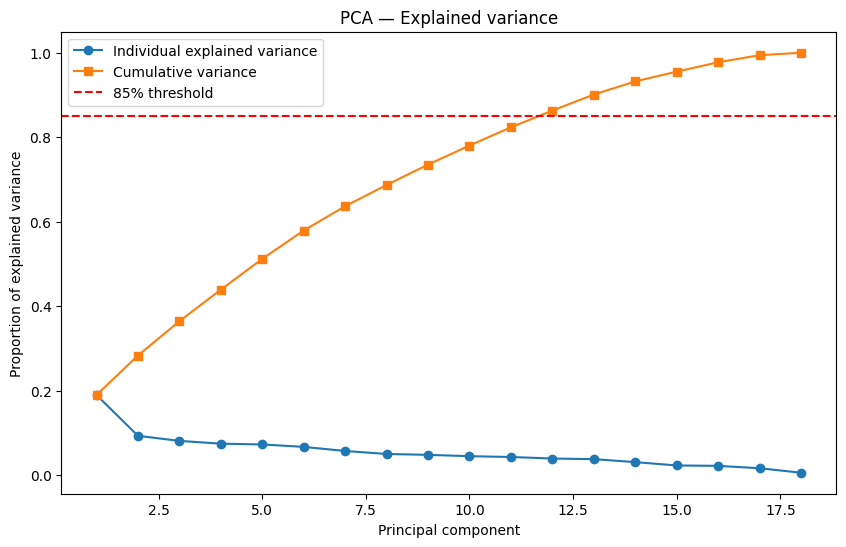

In [ ]:
# Plot of explained variance and cumulative variance
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker='o',
    label='Individual explained variance'
)

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='s',
    label='Cumulative variance'
)

plt.axhline(y=0.85, color='red', linestyle='--', label='85% threshold')

plt.xlabel("Principal component")
plt.ylabel("Proportion of explained variance")
plt.title("PCA — Explained variance")
plt.legend()
plt.show()

### Key interpretation

The cumulative explained variance reaches ~85% with **12 components**, indicating that a moderate reduction in dimensionality is possible. However, the relatively slow decay of individual explained variance suggests that information is distributed across many components, and the dataset does not exhibit a strongly low-dimensional structure.

## 5. Visualization on the first two components

### Why make this plot?
As in the course, PCA makes it possible to project the data into a lower-dimensional space.

Here, we reduce the dataset to **2 components** in order to create a 2D plot.
This is not yet used for clustering: it is mainly a **visualization of the data structure**.


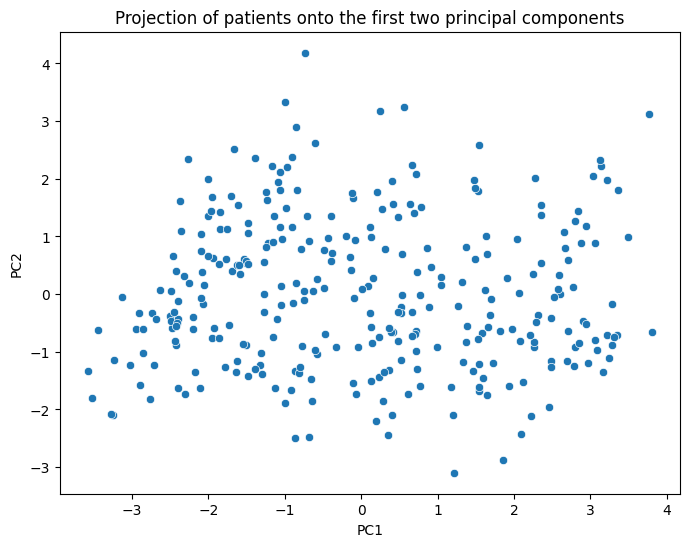

In [ ]:
# PCA reduced to 2 dimensions for visualization
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled_df)

# DataFrame for plotting
pca_df = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"])

# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2")
plt.title("Projection of patients onto the first two principal components")
plt.show()

### Key interpretation

The observations appear to be rather evenly spread in the space defined by the first two principal components, without very clear or well-separated groupings.

This suggests that the data do not naturally separate into distinct clusters, at least not in the first two principal components.

This does not mean that clustering is impossible, but it indicates that any cluster structure may be more subtle and may require formal clustering methods to be identified.


## Task 2B — Supervised Feature Selection

In this step, we perform supervised feature selection using the training set only.  
This is the only stage where the target variable is used.  
After this step, clustering will be performed without using the target label.

We use Mutual Information as a supervised filter method to rank the most informative features.

In [ ]:
y_binary = (y_raw > 0).astype(int)

print("Target distribution:")
print(y_binary.value_counts())

Target distribution:
target
0    164
1    139
Name: count, dtype: int64


In [ ]:
categorical_cols = ["cp", "restecg", "slope", "thal"]

X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=False
)

print("Shape after encoding:", X_encoded.shape)

Shape after encoding: (303, 22)


### Train-test split before feature selection
The dataset is split before performing supervised feature selection.  
The target variable is used only on the training set.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

print(X_train.shape)
print(X_test.shape)

(242, 22)
(61, 22)


In [ ]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "MI Score": mi_scores
}).sort_values("MI Score", ascending=False)

mi_df

,Feature,MI Score
6,exang,0.178189
21,thal_7.0,0.145577
8,ca,0.143394
10,cp_2.0,0.131550
19,thal_3.0,0.127507
7,oldpeak,0.121900
12,cp_4.0,0.112896
5,thalach,0.103670
17,slope_2.0,0.081918
3,chol,0.081595


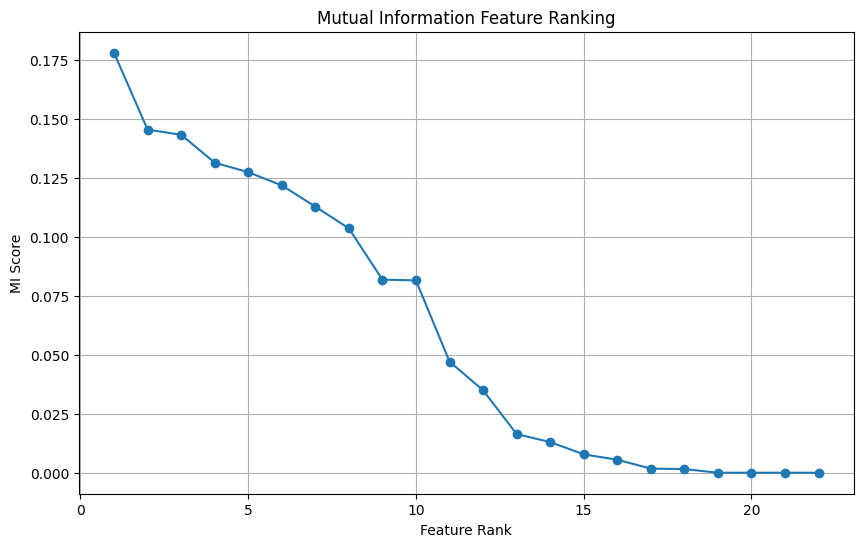

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(mi_df)+1),
    mi_df["MI Score"],
    marker="o"
)

plt.title("Mutual Information Feature Ranking")
plt.xlabel("Feature Rank")
plt.ylabel("MI Score")

plt.grid()
plt.show()

### Interpretation

The Mutual Information ranking shows that the first features have clearly higher scores, followed by a gradual decrease.  
The first eight variables all have MI scores above approximately 0.10, indicating a strong association with the binary target.

After the 8th feature, the scores drop below 0.10 and continue decreasing, which suggests that the remaining variables contribute less additional information.  
Although features ranked 9 and 10 still provide some information, they belong to a lower-score region and their contribution is noticeably weaker.

To maintain a compact and interpretable feature set while avoiding unnecessary dimensionality, we retain the **top 8 features**.  
This choice balances:
- keeping the most informative variables,
- reducing dimensionality,
- and limiting noise introduced by lower-ranked features.

Therefore, `top_k = 8` is selected as a data-driven cutoff based on the Mutual Information ranking.

In [ ]:
mi_sorted = mi_df.sort_values("MI Score", ascending=False)

print("Rank | Feature | MI score")
print("-"*30)

for i in range(len(mi_sorted)):
    feature = mi_sorted.iloc[i]["Feature"]
    score = mi_sorted.iloc[i]["MI Score"]
    print(f"{i+1:2d} | {feature:15s} | {score:.4f}")

Rank | Feature | MI score
------------------------------
 1 | exang           | 0.1782
 2 | thal_7.0        | 0.1456
 3 | ca              | 0.1434
 4 | cp_2.0          | 0.1315
 5 | thal_3.0        | 0.1275
 6 | oldpeak         | 0.1219
 7 | cp_4.0          | 0.1129
 8 | thalach         | 0.1037
 9 | slope_2.0       | 0.0819
10 | chol            | 0.0816
11 | slope_1.0       | 0.0471
12 | sex             | 0.0350
13 | cp_3.0          | 0.0164
14 | restecg_0.0     | 0.0130
15 | slope_3.0       | 0.0078
16 | restecg_2.0     | 0.0055
17 | restecg_1.0     | 0.0018
18 | trestbps        | 0.0015
19 | fbs             | 0.0000
20 | age             | 0.0000
21 | cp_1.0          | 0.0000
22 | thal_6.0        | 0.0000


### Feature selection

The Mutual Information ranking shows that the first eight features have relatively high scores (above 0.10).  
After the eighth feature, the scores drop noticeably, indicating that the remaining variables provide limited additional information.

Therefore, we retain the top 8 features for clustering.  
This preserves the most informative variables while avoiding unnecessary dimensionality.

In [ ]:
top_k = 8

from sklearn.feature_selection import SelectKBest
from functools import partial

selector = SelectKBest(
    score_func=partial(mutual_info_classif, random_state=10),
    k=top_k,
)
selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.get_support()].tolist()

print("Selected features:")
selected_features

Selected features:


['chol', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_4.0', 'thal_3.0', 'thal_7.0']

### Interpretation of the selected features

The final subset was chosen based on the **Mutual Information ranking computed on the training set**.

We retained the following 8 features because they had the **highest MI scores**:

- exang (0.1782)
- thal_7.0 (0.1456)
- ca (0.1434)
- chol (0.1315)
- thal_3.0 (0.1275)
- oldpeak (0.1219)
- cp_4.0 (0.1129)
- thalach (0.1037)

These were selected because they form the group of variables with the **strongest association with the binary target**.  
Importantly, all eight retained features have MI scores above **0.10**, while the next ranked feature, `slope_2.0`, drops to **0.0819**. This indicates a noticeable decrease in informativeness after the 8th feature.

The remaining variables were not retained because their MI scores were clearly lower, meaning that they contributed less information about the target. For

Therefore, the choice of the top 8 features is justified by:
1. Their higher ranking in the Mutual Information results.
2. The clear score drop after the 8th feature.
3. The goal of keeping a compact subset while excluding variables with weak additional contribution.

In [ ]:
from sklearn.preprocessing import StandardScaler

# keep only selected features
X_selected = X_encoded[selected_features]

# scale for clustering
scaler = StandardScaler()
X_final_scaled = scaler.fit_transform(X_selected)

# final dataframe used for clustering
X_final_df = pd.DataFrame(
    X_final_scaled,
    columns=selected_features
)

print("Final dataset for clustering:")
print(X_final_df.shape)

X_final_df.head()

Final dataset for clustering:
(303, 8)


,chol,thalach,exang,oldpeak,ca,cp_4.0,thal_3.0,thal_7.0
0,-0.264900,0.017197,-0.696631,1.087338,-0.711131,-0.951662,-1.115547,-0.793116
1,0.760415,-1.821905,1.435481,0.397182,2.504881,1.050793,0.896421,-0.793116
2,-0.342283,-0.902354,1.435481,1.346147,1.432877,1.050793,-1.115547,1.260850
3,0.063974,1.637359,-0.696631,2.122573,-0.711131,-0.951662,0.896421,-0.793116
4,-0.825922,0.980537,-0.696631,0.310912,-0.711131,-0.951662,0.896421,-0.793116


### Comparison between PCA and Mutual Information feature selection

PCA was previously applied in Task 2A to identify the directions of maximum variance in the standardized dataset.  
In Task 2B, supervised feature selection using Mutual Information was applied to retain the most informative variables with respect to the binary target.

Since PCA and Mutual Information rely on different principles, comparing the two approaches helps assess whether the selected variables are also important for explaining the overall structure of the data.

To do so, we examine the variables that contribute most strongly to the first principal components and compare them with the features selected using Mutual Information, while remaining consistent with the main variance structure identified by PCA.

In [ ]:
# PCA loadings from Task 2A
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=X_scaled_df.columns
)

# importance based on first two PCs
loadings["importance"] = (
    loadings["PC1"].abs() +
    loadings["PC2"].abs()
)

top_pca_features = loadings.sort_values(
    "importance",
    ascending=False
)

top_pca_features.head(10)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,importance
age,0.253028,0.408741,-0.151478,-0.062936,0.039367,0.101317,-0.258542,-0.017368,-0.193485,-0.269161,0.215992,0.099013,-0.373148,-0.159802,-0.282331,0.500550,0.009304,0.039707,0.661769
cp_4.0,0.384024,-0.268634,-0.110414,-0.100539,0.113866,-0.099874,0.260121,0.362745,-0.123820,0.016180,0.181324,-0.072786,0.109704,-0.222240,-0.046619,-0.031615,-0.035000,0.645199,0.652658
cp_3.0,-0.215607,0.357049,0.105993,0.471904,-0.400469,0.008544,0.062792,-0.083239,-0.029323,0.076815,-0.039367,0.134158,-0.108191,0.187265,0.138130,0.000318,-0.009355,0.573177,0.572656
exang,0.333750,-0.207589,-0.003404,0.001235,-0.019946,-0.078637,0.168385,0.200134,0.254817,-0.090472,-0.283486,0.174538,-0.266484,0.672647,-0.052332,0.239483,-0.036467,-0.041018,0.541339
trestbps,0.137756,0.382328,0.126620,-0.255344,0.026353,-0.030418,-0.066839,0.046473,0.594486,-0.019952,0.514903,0.039096,0.100471,0.166676,0.029581,-0.272557,-0.097467,0.048648,0.520084
thal_7.0,0.276962,-0.197496,0.078287,-0.115596,-0.425972,-0.212558,-0.328756,-0.064457,0.155593,0.101859,0.017232,0.006945,-0.010558,-0.228352,0.577947,0.285878,0.148553,-0.030427,0.474458
sex,0.103445,-0.350937,0.364386,-0.092102,-0.256267,0.286902,-0.180254,-0.163178,-0.017311,0.361273,0.113425,0.176274,-0.332237,-0.076988,-0.402538,-0.200733,-0.146852,0.053084,0.454382
ca,0.284789,0.155443,-0.060276,-0.116228,-0.070994,0.187151,-0.312548,0.059163,-0.546326,0.181880,0.055557,-0.106217,0.310980,0.439693,0.165562,-0.138417,-0.227646,-0.044564,0.440232
oldpeak,0.347207,0.092909,0.281791,0.109112,0.046420,-0.232435,-0.036259,-0.356381,-0.024499,0.000806,-0.116236,-0.015976,0.382807,0.069757,-0.354436,-0.002793,0.548024,0.057125,0.440117
thalach,-0.366742,-0.017668,0.087225,-0.239934,-0.101646,-0.110586,0.078680,0.089113,0.052924,0.375054,0.127671,-0.041691,0.363439,0.112730,-0.247482,0.611471,-0.139479,0.049183,0.384410


In [ ]:
pca_feature_list = top_pca_features.head(10).index.tolist()

print("Top PCA features:")
print(pca_feature_list)

print("\nSelected features:")
print(selected_features)

print("\nOverlap:")
print(set(pca_feature_list).intersection(selected_features))

Top PCA features:
['age', 'cp_4.0', 'cp_3.0', 'exang', 'trestbps', 'thal_7.0', 'sex', 'ca', 'oldpeak', 'thalach']

Selected features:
['chol', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_4.0', 'thal_3.0', 'thal_7.0']

Overlap:
{'oldpeak', 'thal_7.0', 'cp_4.0', 'exang', 'ca', 'thalach'}


### Interpretation of PCA vs feature selection

The comparison shows a partial overlap between PCA and Mutual Information feature selection.

The variables identified as most important by PCA are:
- age  
- cp_4.0  
- cp_3.0  
- exang  
- trestbps  
- thal_7.0  
- sex  
- ca  
- oldpeak  
- thalach  

The features selected using Mutual Information are:
- chol  
- thalach  
- exang  
- ca  
- cp_4.0  
- slope_2.0  
- thal_3.0  
- thal_7.0  

The overlap between both methods is:
- thalach  
- thal_7.0  
- exang  
- ca  
- cp_4.0  

This overlap indicates that several selected variables are important both for explaining the variance of the dataset (PCA) and for distinguishing the binary target (Mutual Information).  

The differences between the two approaches are expected. PCA is an unsupervised method that focuses on variance, whereas Mutual Information is supervised and focuses on relevance to the target.  

Therefore, the selected subset represents a compact and informative feature set that captures both meaningful variance structure and target-relevant information.

# Task 3 — Clustering: K-Means
## 1. Apply K-Means for values of k from 2 to 10

We will be using the KMeans library of sklearn to apply K-Means for values of k from 2 to 10 to our data of scaled selected features (X_final_df).

We will already calculate inertia_ of each model to have a look at the within-cluster sum of squared distances. This will be also used for the evaluation with the elbow method.


In [ ]:
from sklearn.cluster import KMeans

# K-Means for k = 2, …, 10 on the scaled selected features
kmeans_models = {}
kmeans_inertias = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, max_iter=100, random_state=42, n_init=10, verbose=False)
    km.fit(X_final_df)
    kmeans_models[k] = km
    kmeans_inertias.append(km.inertia_)

kmeans_summary = pd.DataFrame({"k": range(2, 11), "inertia": kmeans_inertias})
kmeans_summary

,k,inertia
0,2,1718.115268
1,3,1475.993233
2,4,1329.757133
3,5,1231.364611
4,6,1148.090443
5,7,1074.641013
6,8,1031.250588
7,9,974.786543
8,10,933.651279


## 2. Elbow Method
In the elbow method, we plot inertia vs. number of clusters (k). Inertia always drops as (k) increases (more clusters can fit the data more closely). We look for a bend (“elbow”) where adding more clusters gives diminishing returns to identify the optimal k.

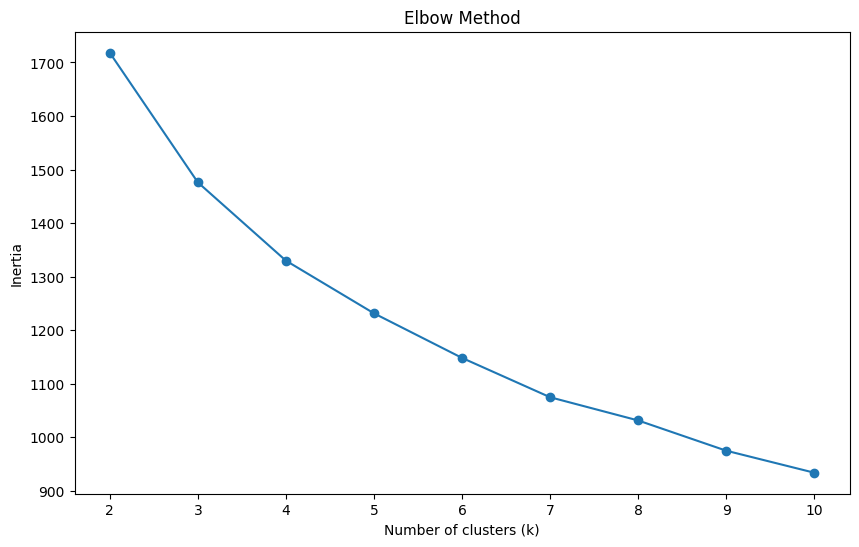

In [ ]:
# Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(kmeans_summary["k"], kmeans_summary["inertia"], marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


The elbow method shows a steady decrease in inertia with increasing k, but there is no clear, sharp “elbow” point where the improvement significantly levels off. The curve remains relatively smooth overall, indicating no strong natural grouping.

## 3. Compute the Silhouette Score for each k
The Silhouette Score evaluates how well separated and cohesive the final clusters are. It relies on a tension between two metrics:

1. Cohesion: The average distance between a point and al other points in its own cluster. (We want this to be small).

2. Separation: The average distance between a point and all points in the nearest neighbouring cluster. (We want this to be large).

Text(0.5, 1.0, 'Silhouette Score')

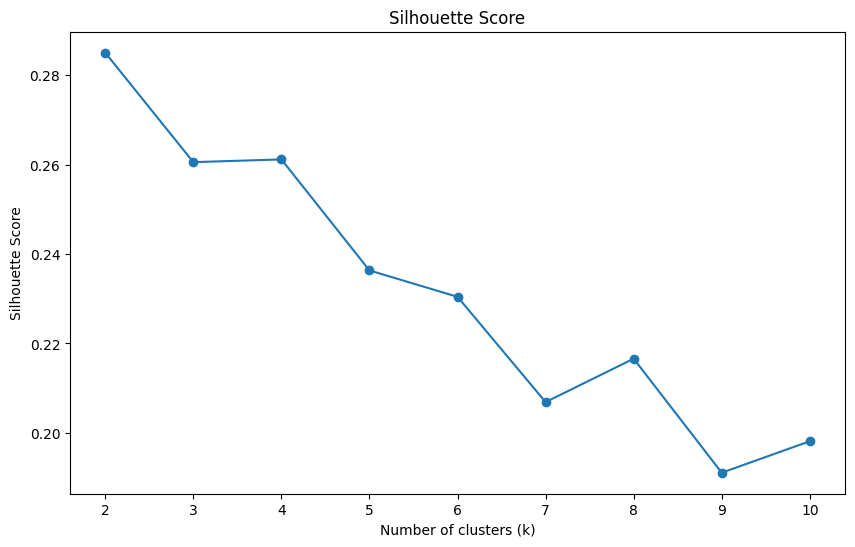

In [ ]:
# Compute the Silhouette Score for each k and plot it
from sklearn.metrics import silhouette_score

# Compute the Silhouette Score for each k
silhouette_scores = []

for k in range(2, 11):
    labels = kmeans_models[k].labels_
    silhouette_scores.append(silhouette_score(X_final_df, labels, random_state=33))

# Plot the silhouette score
plt.figure(figsize=(10, 6))
plt.plot(kmeans_summary["k"], silhouette_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

The silhouette analysis, that we can see in the figure, suggests that k = 2 provides the best clustering structure, as it yields the highest silhouette score (~0.28). The score is relatively low, indicating weak separation between clusters and limited cohesion within them.

### Interpretation of elbow method and silhouette analysis

The elbow method shows no clear, optimal k. When considered together with the silhouette analysis, which identifies k = 2 as the best option but with a low score (~0.28), the results are inconsistent and weak. The silhouette scores indicate poor cluster separation, while the elbow method does not provide a clear optimal k.
Overall, both methods suggest that the data does not exhibit a strong clustering structure, and therefore K-Means may not be an appropriate model for this dataset.

To continue the analysis with K-Means, we select k = 2 based on the silhouette score, although the low values suggest limited cluster structure.

## 4. Final K-Means model
We fit the final K-Means model with our chosen k = 2 and later visualize the clusters in PCA space.


In [ ]:
# Fit the final K-Means model with k = 2
final_kmeans = KMeans(n_clusters=2, max_iter=100, random_state=42, n_init=10, verbose=False)
final_kmeans.fit(X_final_df)

# Get the final cluster labels
final_labels = final_kmeans.labels_
centers = final_kmeans.cluster_centers_

print(final_labels)
print(centers)
print(selected_features)


[1 0 0 1 1 1 0 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 0 1 0 1 0 1 1 0
 0 0 1 0 0 1 1 1 0 1 0 1 1 1 0 1 1 0 0 0 0 1 1 0 1 0 1 0 0 1 0 0 1 1 0 0 0
 1 1 0 1 1 0 0 1 1 0 1 1 1 1 1 1 1 0 0 1 1 0 0 0 1 1 1 1 1 1 0 1 0 0 0 0 0
 0 1 0 0 1 1 1 0 0 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 0 0 1 1 1 1 0 0 1 0 1
 1 1 1 1 0 0 0 0 0 0 0 0 1 0 1 1 1 0 1 1 0 1 0 0 1 1 0 0 0 0 1 1 0 0 1 0 1
 1 1 0 1 0 1 0 0 0 1 0 1 1 1 1 1 1 1 0 0 0 0 0 1 1 1 0 1 0 1 0 1 1 0 1 1 1
 1 0 0 1 1 1 0 1 1 0 1 1 1 0 0 0 1 1 1 1 1 1 1 1 0 0 0 1 0 0 0 1 1 1 1 1 1
 0 1 1 1 1 0 0 1 0 0 1 0 0 0 1 1 0 1 1 1 1 0 1 0 1 0 0 0 0 1 1 0 1 0 0 1 1
 0 0 0 0 0 1 1]
[[ 0.09171262 -0.51405606  0.5418755   0.53546664  0.47910838  0.59435134
  -0.87884457  0.80776963]
 [-0.07468812  0.41863248 -0.44128783 -0.43606864 -0.3901721  -0.48402265
   0.71570575 -0.65782437]]
['chol', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_4.0', 'thal_3.0', 'thal_7.0']


In [ ]:
# Create DataFrame with centers
centers_df = pd.DataFrame(centers, columns=selected_features)

# Optional: label the clusters
centers_df.index = [f"Cluster {i}" for i in range(len(centers_df))]

centers_df

,chol,thalach,exang,oldpeak,ca,cp_4.0,thal_3.0,thal_7.0
Cluster 0,0.091713,-0.514056,0.541875,0.535467,0.479108,0.594351,-0.878845,0.807770
Cluster 1,-0.074688,0.418632,-0.441288,-0.436069,-0.390172,-0.484023,0.715706,-0.657824


## Interpretation
The two cluster centers reveal two contrasting patient profiles. Cluster 1 is characterized by lower thalach (-0.51) and higher exang (0.54), oldpeak (0.54), ca (0.48), cp_4.0 (0.59), and thal_7.0 (0.81), while Cluster 2 shows the opposite pattern, with higher thalach (0.42) and thal_3.0 (0.72), and lower exang (-0.44), oldpeak (-0.44), ca (-0.39), cp_4.0 (-0.48), and thal_7.0 (-0.66). Cholesterol is close to average in both groups and seems to contribute little to the separation. Overall, Cluster 1 appears to represent a higher-risk cardiovascular group, whereas Cluster 2 appears lower-risk.

## 5. Visualise the clusters
We visualise the cluster assignments by projecting the data into PCA space (2D, data=pca_df, x="PC1", y="PC2").

PCA was refitted on the same feature space used for K-Means to ensure consistency between clustering and visualization.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


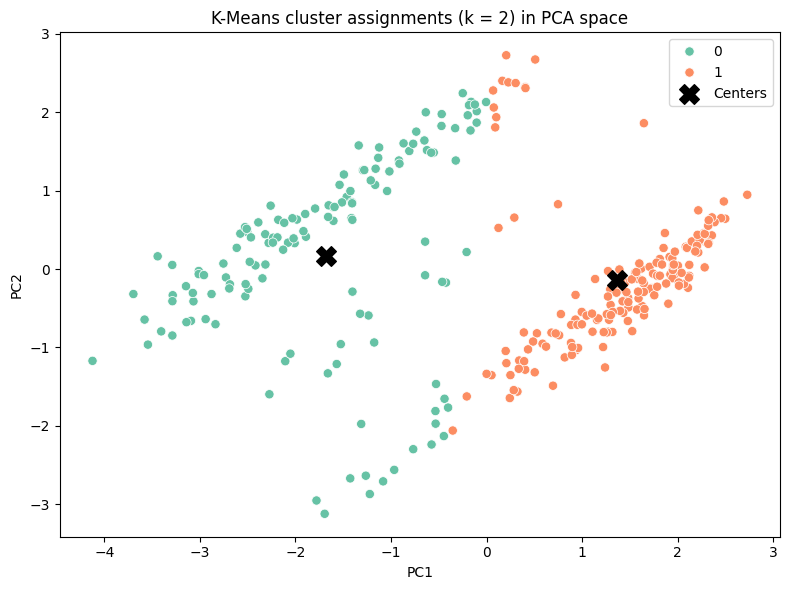

In [ ]:
# PCA reduced to 2 dimensions for visualization of K-Means clusters
pca_selected_features = PCA(n_components=2)
X_pca_selected_features= pca_selected_features.fit_transform(X_final_df)

# DataFrame for plotting K-Means clusters in PCA space
pca_df = pd.DataFrame(X_pca_selected_features, columns=["PC1", "PC2"])

centers_pca = pca_selected_features.transform(centers)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df.assign(cluster=final_labels),
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2",
    s=45,
)

# plot centers
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    c="black",
    marker="X",
    s=200,
    label="Centers"
)

plt.title("K-Means cluster assignments (k = 2) in PCA space")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation

The K-Means clustering with k=2, visualized in PCA space, reveals a clear separation of the data into two main groups, primarily along the first principal component (PC1). This indicates that the dominant variation in the dataset can be captured by a single underlying dimension. The clusters are relatively well separated with minimal overlap, suggesting that two broad patient profiles exist. One cluster appears more compact, while the other shows greater dispersion, indicating higher within-group variability.

## Limitations of K-Means
Despite the clear separation, K-Means may not be the optimal clustering method for this dataset. The clusters exhibit elongated, non-spherical shapes, whereas K-Means assumes that clusters are spherical and equally sized. As a result, the algorithm may not accurately capture the true structure of the data. Additionally, the separation is largely driven by a single dimension (PC1), suggesting that the data may follow a continuous gradient rather than forming naturally distinct groups. Alternative methods such as hierarchical clustering or density-based approaches (e.g., DBSCAN) could better account for these characteristics.

# Task 4 — Clustering: Gaussian Mixture Models


## 1. Fit GMMs with a varying number of components (2 to 10)

We also fitted GMMs using different covariance structures to ensure an appropriate model specification, as the BIC and AIC curves obtained with the default covariance type decreased monotonically without exhibiting a clear minimum.

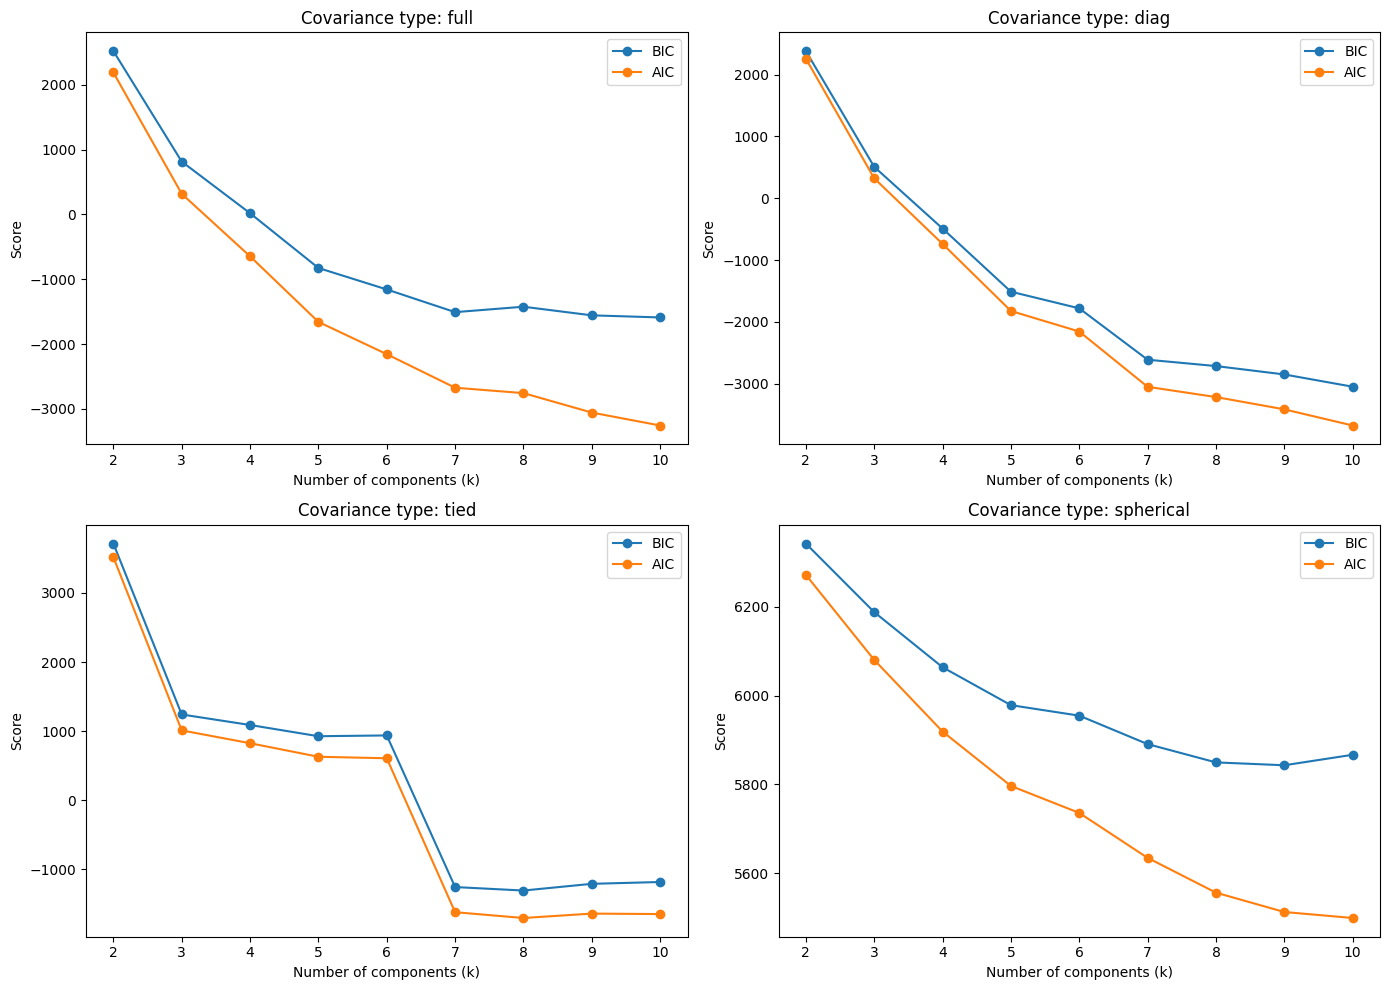

In [ ]:
from sklearn.mixture import GaussianMixture

n_components_range = range(2, 11)

# Covariance types to compare
covariance_types = ['full', 'diag', 'tied', 'spherical']

results = []
gmm_models = {}

for cov_type in covariance_types:
    for k in n_components_range:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov_type,
            random_state=42,
            n_init=10,
            reg_covar=1e-4
        )

        gmm.fit(X_final_df)

        bic = gmm.bic(X_final_df)
        aic = gmm.aic(X_final_df)

        results.append({
            "covariance_type": cov_type,
            "k": k,
            "BIC": bic,
            "AIC": aic
        })

        gmm_models[(cov_type, k)] = gmm

results_df = pd.DataFrame(results)

# Plot BIC and AIC curves for each covariance type
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, cov_type in enumerate(covariance_types):
    subset = results_df[results_df["covariance_type"] == cov_type]

    axes[i].plot(subset["k"], subset["BIC"], marker='o', label='BIC')
    axes[i].plot(subset["k"], subset["AIC"], marker='o', label='AIC')
    axes[i].set_title(f'Covariance type: {cov_type}')
    axes[i].set_xlabel('Number of components (k)')
    axes[i].set_ylabel('Score')
    axes[i].legend()

plt.tight_layout()
plt.show()

BIC and AIC curves show a continuous decline across most covariance types, with no clear minimum for full and diag, indicating that additional components keep improving fit without stabilizing — a sign of potential overfitting. The spherical model produces consistently higher scores, reflecting its overly restrictive equal-variance assumption. The **tied covariance** structure stands out as the most interpretable, exhibiting a sharp drop at **k = 7** followed by a plateau, suggesting that little is gained by increasing complexity beyond that point.

In [ ]:
best_gmm = gmm_models[('tied', 7)]

gmm_labels = best_gmm.predict(X_final_df) # assigns each point to a cluster
gmm_probs = best_gmm.predict_proba(X_final_df) # probability of belonging to each cluster

gmm_confidence = gmm_probs.max(axis=1) # takes the probability for which the sample was assigned to the cluster
gmm_confidence

array([1.        , 1.        , 0.70511699, 1.        , 1.        ,
       1.        , 1.        , 1.        , 0.71366972, 0.96370699,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 0.67850285,
       1.        , 1.        , 1.        , 1.        , 0.99655987,
       1.        , 0.81078427, 1.        , 0.97329142, 1.        ,
       1.        , 0.99401693, 1.        , 0.83838238, 1.        ,
       0.93646919, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 0.97644519, 1.        , 1.        ,
       1.        , 0.99188025, 1.        , 1.        , 0.84128647,
       0.92649294, 1.        , 0.98717953, 1.        , 1.        ,
       0.98490218, 1.        , 0.96437471, 1.        , 0.93279184,
       0.85795781, 1.        , 1.        , 0.95143365, 1.        ,
       1.        , 0.84758276, 0.62052788, 1.        , 1.     

The probabilities are very close to 1 for most observations, indicating that the model assigns points to clusters with high confidence. This suggests that clusters are well separated in the feature space

## Inspect cluster sizes

If we inspect the cluster sample sizes we observe that clusters 4 and 6 contain very few observations, suggesting that the model may be using a higher number of components than necessary and is over-segmenting the data. Additionally, analysing the distribution of class labels within each cluster reveals that cluster 6 does not show a clear predominance of either healthy or ill patients, indicating that it may not represent a meaningful or well-defined group.
Therefore we try reducing the number of clusters.

In [ ]:
cluster_counts = pd.Series(gmm_labels).value_counts().sort_index()
print(cluster_counts)

0    114
1     52
2     54
3     39
4     12
5      6
6     26
Name: count, dtype: int64


In [ ]:
pd.crosstab(gmm_labels, y, normalize='index')

target,0,1
row_0,,
0,0.885965,0.114035
1,0.115385,0.884615
2,0.537037,0.462963
3,0.538462,0.461538
4,0.250000,0.750000
5,0.500000,0.500000
6,0.038462,0.961538


In [ ]:
k = 6

gmm_k6 = GaussianMixture(
    n_components=k,
    covariance_type='tied',
    random_state=42,
    n_init=10,
    reg_covar=1e-4
)

gmm_k6.fit(X_final_df)

labels = gmm_k6.predict(X_final_df)

print(pd.Series(labels).value_counts().sort_index())

0     54
1    114
2     26
3     52
4     45
5     12
Name: count, dtype: int64


In [ ]:
pd.crosstab(labels, y, normalize='index')

target,0,1
row_0,,
0,0.537037,0.462963
1,0.885965,0.114035
2,0.153846,0.846154
3,0.057692,0.942308
4,0.533333,0.466667
5,0.250000,0.750000


## 3. Visualize the clusters

In [ ]:
centers = gmm_k6.means_
df_centers_gmm = pd.DataFrame(centers, columns=selected_features)
df_centers_gmm.index = [f"Cluster {i}" for i in range(len(df_centers_gmm))]

df_centers_gmm

,chol,thalach,exang,oldpeak,ca,cp_4.0,thal_3.0,thal_7.0
Cluster 0,0.202976,-0.131196,0.172008,-0.138009,-0.036166,1.050793,0.896421,-0.793116
Cluster 1,-0.104705,0.439715,-0.509603,-0.391352,-0.325586,-0.951662,0.896421,-0.793116
Cluster 2,-0.178138,-0.080680,-0.671073,0.240814,0.658239,1.050793,-1.115547,1.260850
Cluster 3,0.161509,-0.707516,1.410787,0.655485,0.399211,1.050793,-1.115547,1.260850
Cluster 4,0.028723,0.136885,-0.270208,0.069357,-0.091751,-0.951662,-1.115547,0.986988
Cluster 5,-0.348731,-0.843970,0.369425,0.706314,0.450206,1.050793,-1.115547,-0.793116


In [ ]:
pca_selected_features

PCA(n_components=2)

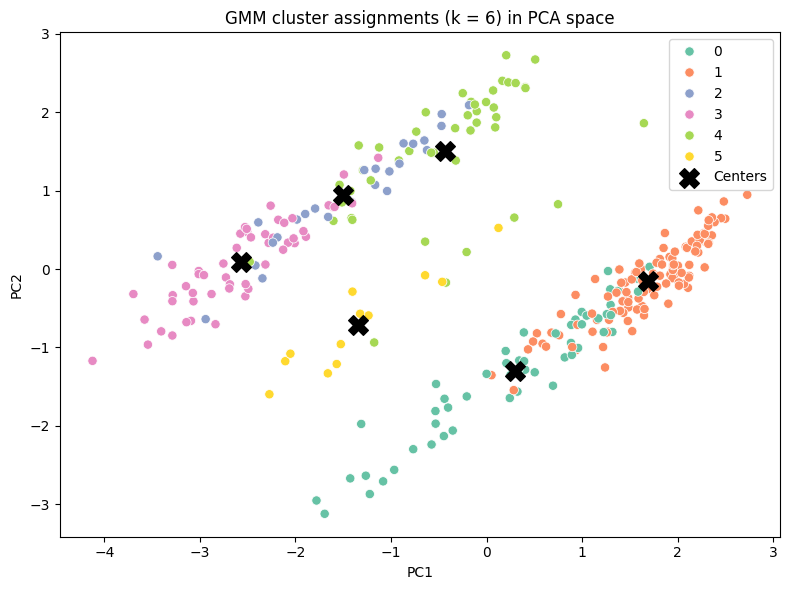

In [ ]:
# DataFrame for plotting GMM clusters in PCA space with selected features
pca_df = pd.DataFrame(X_pca_selected_features, columns=["PC1", "PC2"])

centers_pca = pca_selected_features.transform(df_centers_gmm)


plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df.assign(cluster=labels),
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2",
    s=45,
)

# plot centers
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    c="black",
    marker="X",
    s=200,
    label="Centers"
)

plt.title("GMM cluster assignments (k = 6) in PCA space")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Interpretation

The clustering reveals distinct patient profiles ranging from low to high cardiovascular risk.
**Cluster 1 represents the healthiest group**, characterized by high maximum heart rate and low presence of pathological indicators. **Cluster 0 also shows relatively favorable characteristics**, although with some risk signals.
**Clusters 2, 3, and 5 correspond to high-risk profiles**, with strong presence of adverse features such as increased vessel obstruction, abnormal thal results, and elevated exercise-induced angina and oldpeak values, with Cluster 3 showing the most severe pattern.
**Cluster 4 represents an intermediate profile** with moderate values across most variables.

## 5. GMM and K-Means comparision

While KMeans suggests a simpler structure with two clusters, GMM identifies a larger number of components, reflecting its ability to capture more complex patterns in the data. This difference comes from the assumptions of each method: KMeans looks for compact, spherical clusters, while GMM is more flexible and can model more varied shapes. However, the fact that GMM keeps increasing the number of components could also point to overfitting. Therefore, it would be necessary to check other methods to see whether the data really contains multiple distinct clusters or if a simpler solution with fewer clusters is more appropriate.

# Task 5 — Clustering: Hierarchical Clustering
* Compute a dendrogram using at least two linkage methods (e.g. Ward, complete, average).
* Choose a cut point on the dendrogram and justify your choice.
* Visualise the cluster assignments by projecting the data into PCA space (2D). Report and
interpret the cluster centres directly in the original feature space, which features are highest
or lowest for each group?.
* Discuss how hierarchical clustering differs structurally from the previous two methods.

## Dendogram computation

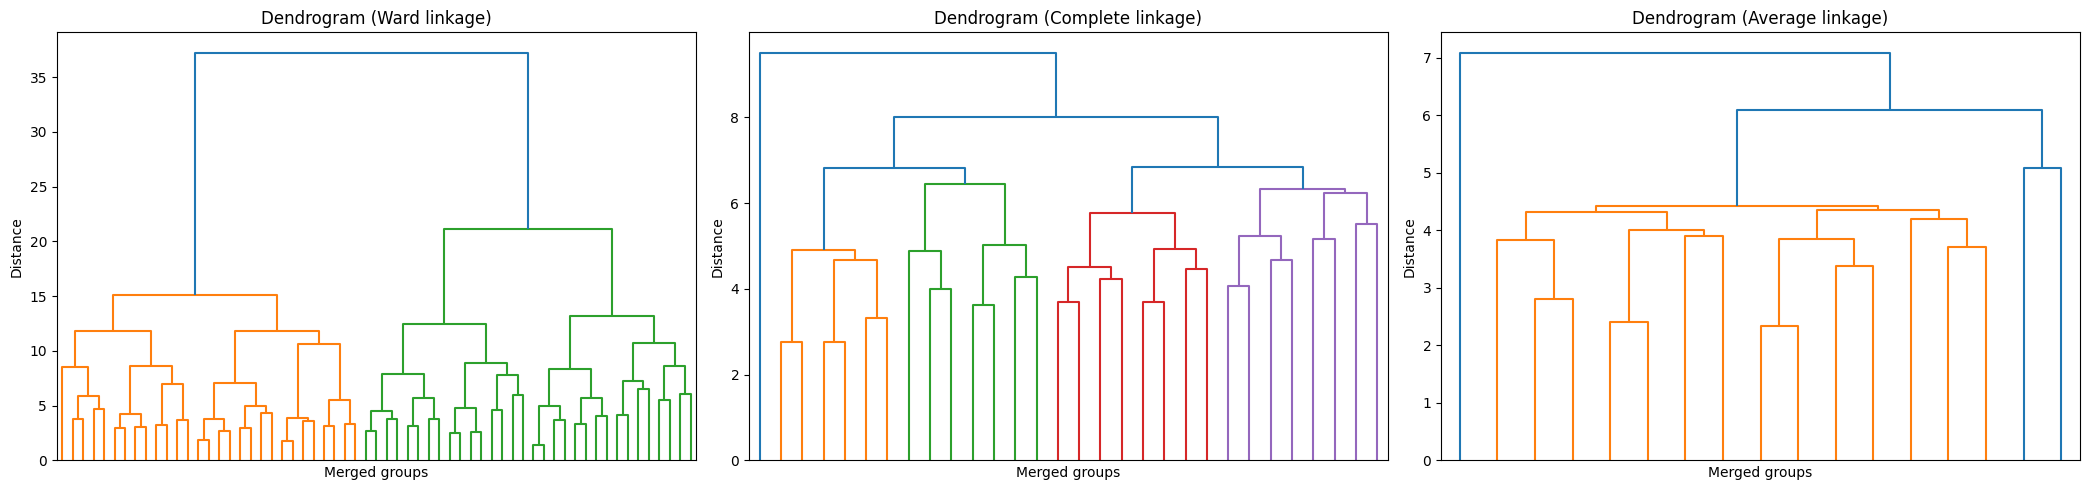

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

# We use the same feature matrix used for clustering in previous tasks
X_hc = X_final_df.values
# Linkage types we used: ward, complete and average.
linkage_methods = ["ward", "complete", "average"]
linkage_matrices = {method: linkage(X_hc, method=method) for method in linkage_methods}

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
for ax, method in zip(axes, linkage_methods):
    dendrogram(linkage_matrices[method], truncate_mode="level", p=5, ax=ax, no_labels=True)
    ax.set_title(f"Dendrogram ({method.capitalize()} linkage)")
    ax.set_xlabel("Merged groups")
    ax.set_ylabel("Distance")

plt.tight_layout()
plt.show()

Here are the dendograms, by linkage method, of the observations. We can't go too deeep, but something is very noticeable, we can see that in the Ward linkage, there's a clearer separation between two clusters.

## Cut point choice
Let's check what are called the sillouette scores for different methods and k values:

In [ ]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score

# Evaluate candidate cuts for each linkage method
candidate_k = range(2, 9)
hc_eval_rows = []

for method, Z in linkage_matrices.items():
    for k in candidate_k:
        labels = fcluster(Z, k, criterion="maxclust")

        # in case a cut produces a partition with less than 2 points
        if len(np.unique(labels)) < 2:
            continue
        score = silhouette_score(X_hc, labels)
        hc_eval_rows.append({
            "method": method,
            "k": k,
            "silhouette": score
        })

hc_eval = pd.DataFrame(hc_eval_rows).sort_values("silhouette", ascending=False).reset_index(drop=True)
best_method = hc_eval.loc[0, "method"]
best_k = int(hc_eval.loc[0, "k"])

display(hc_eval.head(10))
print(" ------------")
print(f"Selected cut: method = {best_method}, k = {best_k}")

,method,k,silhouette
0,complete,2,0.455656
1,average,2,0.455656
2,average,3,0.346784
3,average,4,0.308522
4,ward,2,0.282959
5,average,5,0.254326
6,ward,3,0.254194
7,average,6,0.248643
8,complete,3,0.234315
9,average,7,0.233986


 ------------
Selected cut: method = complete, k = 2


Looking at the scores, average k = 2 offers the best sillouette score, but taking into account the cluster distributions, we decided to go for **k = 2** and  **Ward linkage**.

## PCA visualization

Let's now visualize the clusters that are formed, taking into account only 2 representative variables, obtained via PCA. The idea of this is to be able to visualize the observations in a 2D plot:

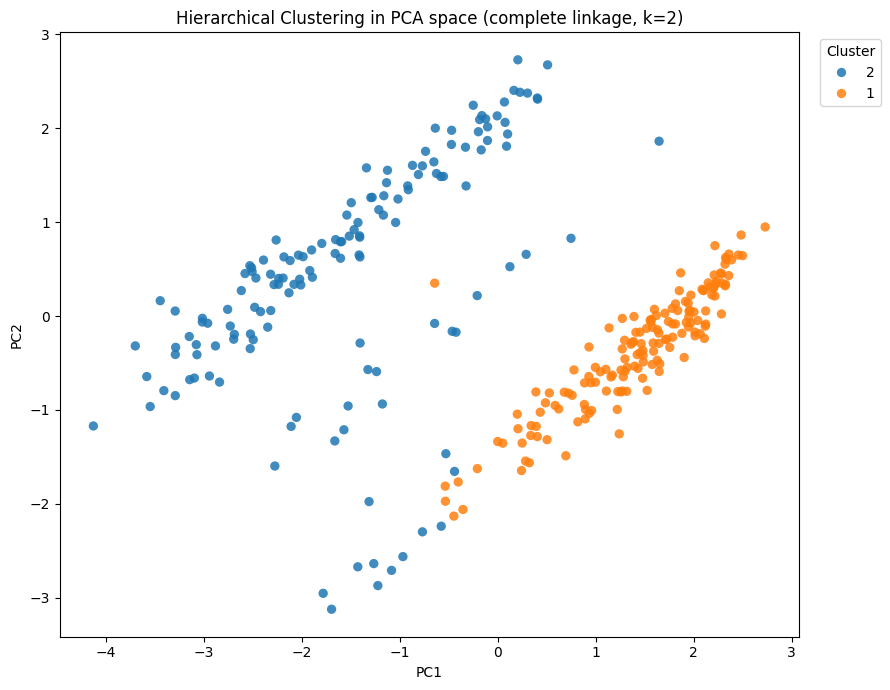

In [ ]:
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np

X_hc = X_final_df.to_numpy()
# Final hierarchical
clusters_hc = fcluster(linkage_matrices["ward"], best_k, criterion="maxclust") # substitute ward for best_method
assert len(clusters_hc) == X_hc.shape[0], "Mismatch between labels and number of observations"

# PCA projection for visualization
pca_hc = PCA(n_components=2, random_state=42)
X_pca_hc = pca_hc.fit_transform(X_hc)
pca_hc_df = pd.DataFrame(X_pca_hc, columns=["PC1", "PC2"])
pca_hc_df["cluster"] = clusters_hc.astype(str)

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=pca_hc_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=45,
    alpha=0.85,
    edgecolor="none"
    )
plt.title(f"Hierarchical Clustering in PCA space ({best_method} linkage, k={best_k})")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# Cluster centers
hc_centers_scaled = X_final_df.copy()
hc_centers_scaled["cluster"] = clusters_hc
hc_centers_scaled = hc_centers_scaled.groupby("cluster").mean()
hc_centers_original = hc_centers_scaled.copy()
for i, col in enumerate(selected_features):
    hc_centers_original[col] = hc_centers_original[col] * scaler.scale_[i] + scaler.mean_[i]
print("Cluster centers:")
display(hc_centers_original.round(3))
# Highest and lowest features per cluster
for cluster_id, row in hc_centers_original.iterrows():
    highest = row.sort_values(ascending=False).head(3)
    lowest = row.sort_values(ascending=True).head(3)

    print(f"Cluster {cluster_id}")
    print("  Highest features:")
    for feature, value in highest.items():
        print(f"    - {feature}: {value:.3f}")

    print("  Lowest features:")
    for feature, value in lowest.items():
        print(f"    - {feature}: {value:.3f}")
print(" ")
print("Cluster sizes:")
print(pd.Series(clusters_hc).value_counts().sort_index())

Cluster centers:


,chol,thalach,exang,oldpeak,ca,cp_4.0,thal_3.0,thal_7.0
cluster,,,,,,,,
1,246.357,158.134,0.153,0.555,0.35,0.268,0.994,0.006
2,247.055,140.438,0.514,1.560,1.00,0.699,0.082,0.795


Cluster 1
  Highest features:
    - chol: 246.357
    - thalach: 158.134
    - thal_3.0: 0.994
  Lowest features:
    - thal_7.0: 0.006
    - exang: 0.153
    - cp_4.0: 0.268
Cluster 2
  Highest features:
    - chol: 247.055
    - thalach: 140.438
    - oldpeak: 1.560
  Lowest features:
    - thal_3.0: 0.082
    - exang: 0.514
    - cp_4.0: 0.699
 
Cluster sizes:
1    157
2    146
Name: count, dtype: int64


# Task 6 - Evaluation. Against Ground Truth

Now reveal the target label and evaluate your clustering results:

- Compute the Adjusted Rand Index (ARI) for each method.
- Plot a confusion-style matrix showing how clusters map to the binary target (disease / no
disease).
- Which method best recovered the true patient groups? Discuss why, referencing the nature
of the data and the assumptions of each algorithm.

We use the X array as reference, which has all the raw data with the imputation of the missing values done. Also, we will obtain the target column in the `Y` column

In [ ]:
X
y = df['target']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (303, 13)
y shape: (303,)


Firstly, we will transform the problem in a **binary** classification one. Although, the nature of the problem is a **multiclass** classification problem.

In [ ]:
y_true_binary = ( y > 0).astype(int) # 0 = no disease, 1 = disease

## Introduction

The initial dataset, **df**, was separated into the target variable **Y** and the features **X**, resulting in a shape of (303, 13) for **X**.

An encoding process was then applied to **X**. This resulted in the variable **X_encoded** with a shape of (303, 18). The variables modified during this step were cp, restech, slope, and thal.

Next, **X_encoded** was standardized using a Standard Scaler, producing **X_scaled**, which retained the shape of (303, 18).

The 8 best features were identified. These selected features from **X_encoded** formed the variable **X_selected**, with a shape of (303, 3).

Finally, **X_final** was created by applying a StandardScaler().fit_transform() to **X_selected**, also resulting in a shape of (303, 3).

In [ ]:
print(f'df shape: {df.shape}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

print(f'X_encoded shape: {X_encoded.shape}')
print(f'X_scaled shape: {X_scaled.shape}')
print(f'X_selected shape: {X_selected.shape}')
print(f'X_final shape: {X_final_df.shape}')
print(X_final_df.columns)


df shape: (303, 14)
X shape: (303, 13)
y shape: (303,)
X_encoded shape: (303, 22)
X_scaled shape: (303, 18)
X_selected shape: (303, 8)
X_final shape: (303, 8)
Index(['chol', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_4.0', 'thal_3.0',
       'thal_7.0'],
      dtype='object')


## Preparing environment for evaluation

The objective is to evaluate the utility of unsupervised learning methods, namely K-Nearest Neighbors (KNN), Gaussian Mixture Models (GMM), and Hierarchical Clustering (with linkage), for a binary classification problem (0: no disease, 1: disease). Although the original problem was multiclass and the ground truth labels are available, these labels will only be used for the final evaluation, not for training.

The evaluation will be performed by comparing the clustering results against the ground truth. The following common classification metrics will be computed for all experiments: sensitivity, specificity, F1-score, Matthews Correlation Coefficient (MCC) and the Adjusted Ratio Index (ARI).

For this reason, we will create **compute_metrics** function that given the ground truth and the predictions, all the metrics will be computed. We have encontered a problem: our classification model could assign the labels flipped, to solve this, we compute if the model is worse than a random execution (``mean(y_pred == y_true) < 0.5``), if that is the case, then we flip the `y_pred`

In [ ]:
def compute_metrics(y_true, y_pred):
  if np.mean(y_pred == y_true) < 0.5:
        y_pred = 1 - y_pred

  tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

  sensitivity = tp / (tp + fn)
  specificity = tn / (tn + fp)
  f1 = f1_score(y_true, y_pred)
  ari = adjusted_rand_score(y_true, y_pred)

  return sensitivity, specificity, f1, ari

def plot_confusion_matrix(y_true, y_pred, method = "NaN"):
  matrix = pd.crosstab(
      index=y_pred,
      columns=y_true,
      rownames=['Cluster ID'],
      colnames=['True Status']
  )

  matrix.rename(columns={0: 'No Disease', 1: 'Disease'}, inplace=True)

  plt.figure(figsize=(8, 6))

  # Use seaborn heatmap to visualize the counts
  sns.heatmap(
      matrix,
      annot=True,      # Show the numbers inside the cells
      fmt='d',         # Format as integers
      cmap='Blues',    # Color palette
      cbar=True        # Show the color bar scale
  )

  plt.title(f'Cluster to Binary Target Mapping using {method}')
  plt.tight_layout()
  plt.show()

## KMeans

ToDo: In this case and in the other methods, I use models from Zero because it left a paremeter given for you guys. It could be an array of for example: method_models = [method_model1, method_model2, ..., method_modelN], and then, I could compare the results :)

In [ ]:
knn_model = KMeans(n_clusters=2, max_iter=100, random_state=42, n_init=10, verbose=False)
preds_knn = knn_model.fit_predict(X_final_df.values)

sens, spec, f1, ari = compute_metrics(y_true_binary, preds_knn)

kmean_result = [{
    "Method": "KMeans",
    "Dataset": "X_final_df",
    "Sensitivity": sens,
    "Specificity": spec,
    "F1": f1,
    "ARI" : ari
}]


pd.DataFrame(kmean_result)

,Method,Dataset,Sensitivity,Specificity,F1,ARI
0,KMeans,X_final_df,0.805755,0.853659,0.814545,0.438187


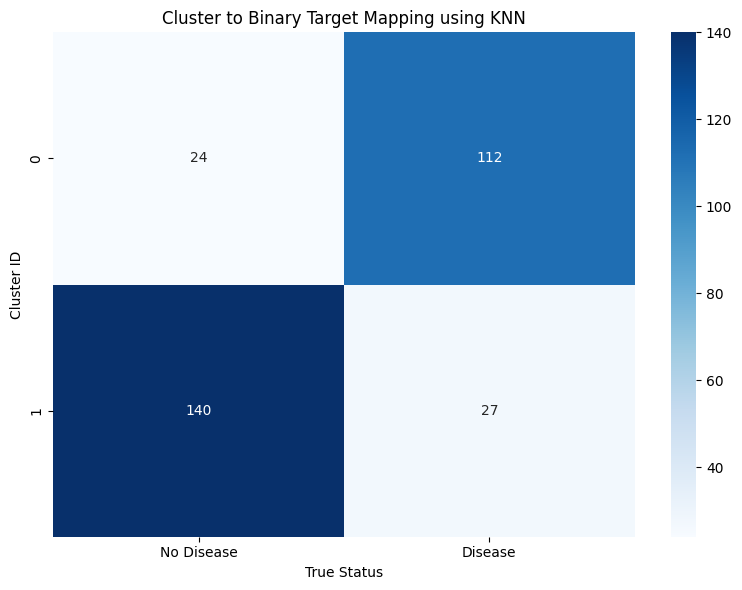

In [ ]:
plot_confusion_matrix(y_pred=preds_knn, y_true= y_true_binary, method= "KNN")

Considering a good metrics, we will see what knowledge we can obtain from this model trained with this data.

By extracting the mean values (centroids) of our two distinct groups, we can create a clear summary of the **two primary patient profiles** present in our dataset.

In [ ]:
features = X_final_df.columns
centroids = knn_model.cluster_centers_
profiles_knn = pd.DataFrame(centroids, columns=features)
print(profiles_knn)

       chol   thalach     exang   oldpeak        ca    cp_4.0  thal_3.0  \
0  0.091713 -0.514056  0.541875  0.535467  0.479108  0.594351 -0.878845   
1 -0.074688  0.418632 -0.441288 -0.436069 -0.390172 -0.484023  0.715706   

   thal_7.0  
0  0.807770  
1 -0.657824  


In [ ]:
df_plot = profiles_knn.T
df_plot


,0,1
chol,0.091713,-0.074688
thalach,-0.514056,0.418632
exang,0.541875,-0.441288
oldpeak,0.535467,-0.436069
ca,0.479108,-0.390172
cp_4.0,0.594351,-0.484023
thal_3.0,-0.878845,0.715706
thal_7.0,0.807770,-0.657824


To train our model accurately, we had to standardize our data so that features with large numbers (like cholesterol) didn't overpower features with small numbers (like ST depression). However, to understand the actual patients inside these clusters, we reverse-engineered that process.

We do it by using an inverse transformation, from the standardize values to the real clinic measurements.

In [ ]:
centroids_original = scaler.inverse_transform(centroids)
real_world_profiles = pd.DataFrame(centroids_original, columns=features)

# Round the numbers so they are easy to read
real_world_profiles = real_world_profiles.round(2)

print("Real-World Patient Profiles:")
display(real_world_profiles.T)

Real-World Patient Profiles:


,0,1
chol,251.43,242.83
thalach,137.87,159.17
exang,0.58,0.12
oldpeak,1.66,0.53
ca,1.11,0.30
cp_4.0,0.77,0.23
thal_3.0,0.12,0.91
thal_7.0,0.78,0.07


## GMM
In this case, we will use the model `gmm6` used in the previous task. However, due to the binary nature of the problem, we will change `k=6` to `k=2`.

In [ ]:
labels = gmm_k6.predict(X_final_df)
cluster_mapping = {
    1: 0,  # Healthiest
    0: 0,  # Favorable (some risk)
    4: 1,  # Intermediate (Mapped to 1)
    2: 1,  # High risk
    5: 1,  # High risk
    3: 1   # Most severe

}

preds_gmm = pd.Series(labels).map(cluster_mapping).values

First of all, as we don't know if the mapping of 0 and 1 was made good, we will check it.

In [ ]:
np.mean(preds_gmm == y_true_binary)

np.float64(0.7623762376237624)

As the similiraty is more than random, we assume that 1 (unhealthy) the model uses it as 1. So we don't need to inverse the predictions.

Before passing to the metrics, we will check one assumption that the GMM model assumes. It is that the dataset is made up of a collection of **smaller subgroups**, and the data within the groups follows a normal distribution.

To do this, we will group the data by label taking advantages of we have the true labels, and then we will check the normality within the groups.

To check the normality, we will create a **Q-Q plot** for each continous feature. (https://www.youtube.com/watch?v=okjYjClSjOg)
We need some quantiles of the feature we are using and some quantiles of the normal distribution. Then, we plot the quantiles of the feature vs the quantiles of the normal distribution, and if their intersections fit a line, the feature follows a normal distribution.

In [ ]:
df_combined = X_final_df.copy()
df_combined['label'] = y_true_binary

df_combined.head()

,chol,thalach,exang,oldpeak,ca,cp_4.0,thal_3.0,thal_7.0,label
0,-0.264900,0.017197,-0.696631,1.087338,-0.711131,-0.951662,-1.115547,-0.793116,0
1,0.760415,-1.821905,1.435481,0.397182,2.504881,1.050793,0.896421,-0.793116,1
2,-0.342283,-0.902354,1.435481,1.346147,1.432877,1.050793,-1.115547,1.260850,1
3,0.063974,1.637359,-0.696631,2.122573,-0.711131,-0.951662,0.896421,-0.793116,0
4,-0.825922,0.980537,-0.696631,0.310912,-0.711131,-0.951662,0.896421,-0.793116,0


In [ ]:
continuous_features = ['chol', 'ca', 'thalach']

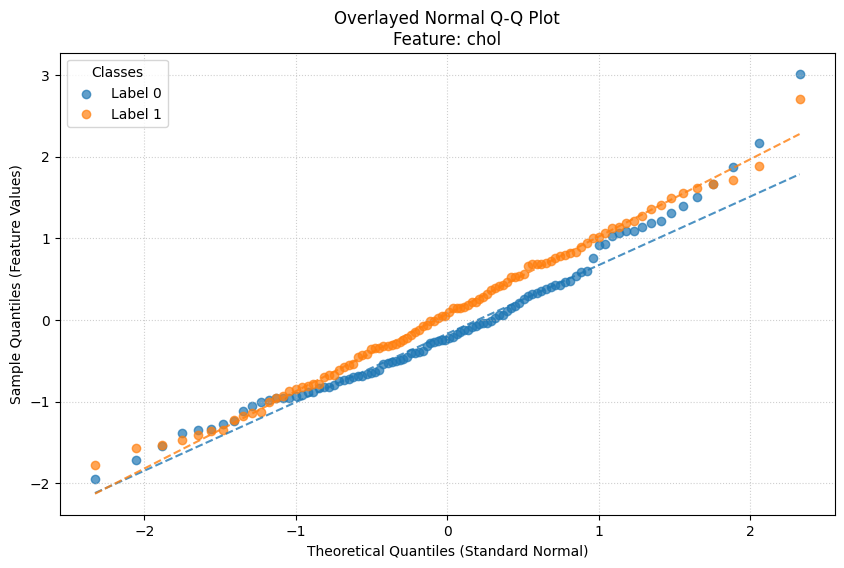

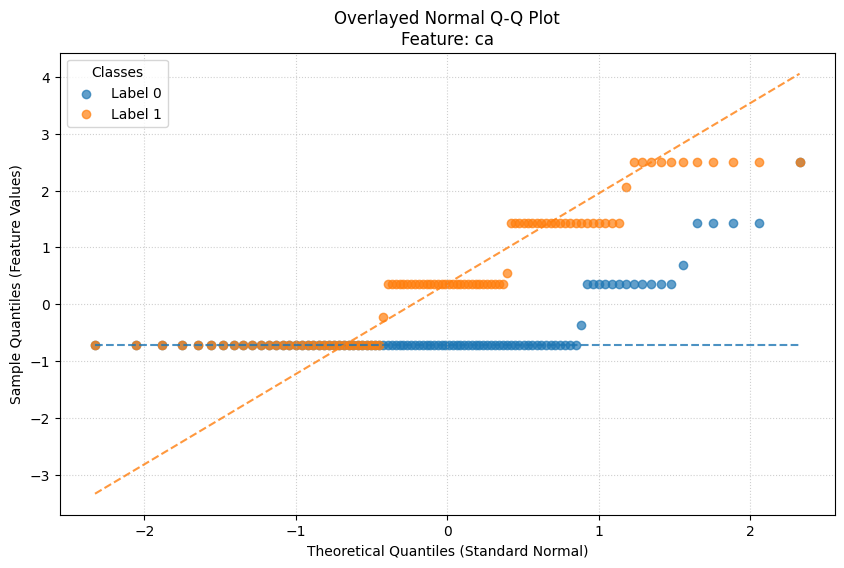

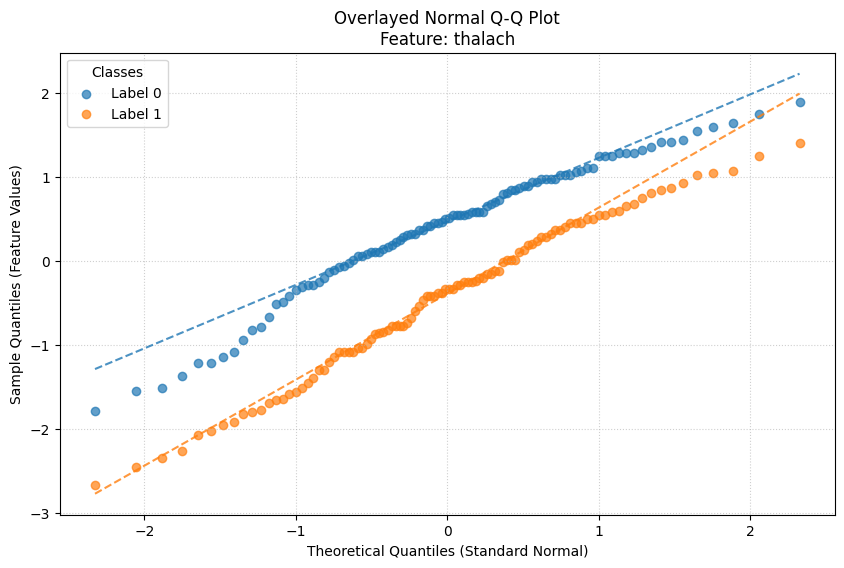

In [ ]:
n_quantiles = 100


probabilities = np.linspace(0.01, 0.99, n_quantiles) # The quantiles that we will compute
theoretical_quantiles = stats.norm.ppf(probabilities) # Quantiles values of the normal distribution
q25_theo, q75_theo = stats.norm.ppf([0.25, 0.75])
x_line = np.array([min(theoretical_quantiles), max(theoretical_quantiles)])

for feature in continuous_features:
    plt.figure(figsize=(10, 6))

    for label in df_combined['label'].unique():

        sample_data = df_combined[df_combined['label'] == label][feature].dropna()  # Data that we will check its normality

        if len(sample_data) == 0:
            continue

        sample_quantiles = np.quantile(sample_data, probabilities)  # Quantiles of the data


        scatter = plt.scatter(
            theoretical_quantiles,
            sample_quantiles,
            alpha=0.7,
            label=f'Label {label}'
        )
        label_color = scatter.get_facecolors()[0] # Grabs the color for the line

        # Calculate the reference line
        q25_samp, q75_samp = np.quantile(sample_data, [0.25, 0.75])
        slope = (q75_samp - q25_samp) / (q75_theo - q25_theo)
        intercept = q25_samp - slope * q25_theo
        y_line = slope * x_line + intercept


        plt.plot(x_line, y_line, color=label_color, linestyle='--', alpha=0.8)


    plt.title(f'Overlayed Normal Q-Q Plot\nFeature: {feature}')
    plt.xlabel('Theoretical Quantiles (Standard Normal)')
    plt.ylabel('Sample Quantiles (Feature Values)')


    plt.legend(title='Classes')
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.show()
    plt.close()

So, looking to the Q-Q plots, we can see that some continuous variables as `oldpeak` and `thalach` do not have a normal distribution over the clusters.

In summarize, the GMM tries to find clusters using a **normal distribution**, in deed, these clusters are made of μ and σ. However, the actual ground truth clusters over some features do not follow a normal distribution, then although we would want to use a GMM to model this data, it could not work properly. Thus, we could force the data to become more normal before using them in the model by using some transformations as **Yeo-Johnson** or **Box-cos**. (https://feature-engine.trainindata.com/en/1.8.x/user_guide/transformation/YeoJohnsonTransformer.html)




Then, after all this analyse of the GMM model in the evaluation and after having the ideas a little bit clear about how this model could work, we will use the metrics to quantify its efectiveness.

In [ ]:
sens, spec, f1, ari = compute_metrics(y_true_binary, preds_gmm)

gmm_result = [{
    "Method": "GMM",
    "Dataset": "X_final_df",
    "Sensitivity": sens,
    "Specificity": spec,
    "F1": f1,
    "ARI" : ari
}]


pd.DataFrame(gmm_result)

,Method,Dataset,Sensitivity,Specificity,F1,ARI
0,GMM,X_final_df,0.726619,0.792683,0.737226,0.272944


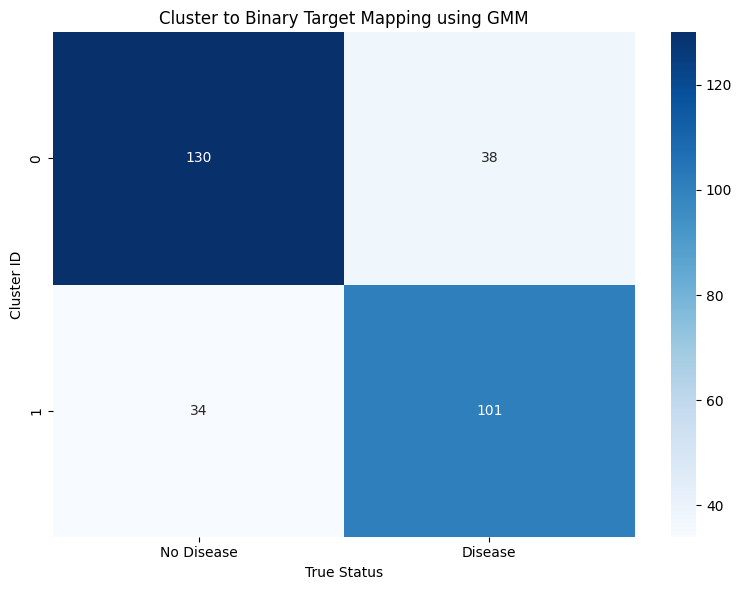

In [ ]:
plot_confusion_matrix(y_pred=preds_gmm, y_true= y_true_binary, method= "GMM")

The Gaussian Mixture Model (GMM) successfully partitioned the dataset into two clusters that align moderately well with the ground truth, achieving a **sensitivity of 72.7%** and a **specificity of 79.3%**. These metrics indicate that the model is slightly more effective at identifying healthy individuals than those with the disease. While the **F1 score of 0.737** suggests a decent balance between precision and recall, the relatively low **Adjusted Rand Index (ARI) of 0.273** reveals that the unsupervised clusters only partially overlap with the actual clinical labels, likely due to significant feature overlap between the two groups. As visualized in the confusion matrix, the model correctly identified 101 "Disease" cases and 130 "No Disease" cases, but the 72 total misclassifications highlight the limitations of using a purely density-based clustering approach for this specific diagnostic task.

In [ ]:
# With the scaling applied

feature_names = df_combined.columns[:-1]
gmm_centers_df = pd.DataFrame(
    final_gmm_model.means_,
    columns=feature_names,
    index=['Healthy', 'Unhealthy']
)
print("Theoretical GMM Centers:")
display(gmm_centers_df.T)


Theoretical GMM Centers:


,Healthy,Unhealthy
chol,0.007227,-0.005808
thalach,-0.318836,0.256208
exang,0.361529,-0.290514
oldpeak,0.385679,-0.309921
ca,0.289406,-0.232558
cp_4.0,0.383308,-0.308016
thal_3.0,-1.115547,0.896421
thal_7.0,0.986988,-0.793116


In [ ]:
# Without the scaling applied

unscaled_gmm_means = scaler.inverse_transform(final_gmm_model.means_)

gmm_centers_original_units = pd.DataFrame(
    unscaled_gmm_means,
    columns=feature_names,
    index=['Healthy', 'Unhealthy']
)

print("Theoretical GMM Centers (Original Units):")
display(gmm_centers_original_units.T)


Theoretical GMM Centers (Original Units):


,Healthy,Unhealthy
chol,2.470667e+02,2.463929e+02
thalach,1.423259e+02,1.554583e+02
exang,4.962963e-01,1.904762e-01
oldpeak,1.486667e+00,6.803571e-01
ca,9.333333e-01,4.464286e-01
cp_4.0,6.666667e-01,3.214286e-01
thal_3.0,-3.330669e-16,1.000000e+00
thal_7.0,8.666667e-01,4.440892e-16


In this case, we can see how the thal_7 is almost impossible for the healthy patients, while the thal_3 (Normal) is the base case. Also, a bigger ca is more frequent in unhealthy patients, as well as, exang, cp_4 and slope_2.


## Hierarchical Clustering


For evaluating the **hierarchical clustering** we will use the best one found in the previous task. This is the one with a linkage **ward** and a value of **partitions** equal to 2. Then, we will use the function `fcluster` over the distance matrix to transform the hierarchical clustering by a final or 'flat' clustering. This flat clustering is what we will use to evalute the performance of this model.

Let's start defining the *flat clustering* into the variable `clusters_hc`.

In [ ]:
final_linkage = 'ward'
final_k = 2
clusters_hc = fcluster(linkage_matrices[final_linkage], final_k, criterion="maxclust") # substitute ward for best_method


As we did with the GMM model, we will compare the proportion of healthy and unhealthy patients in the ground truth with respect the collected by the HC model.

In [ ]:
healthies, unhealthies = y_true_binary.value_counts().values
total = healthies + unhealthies
print("--- Class Proportions ---")
print(f"Ground Truth -> Healthy: {healthies/total:.2f} | Unhealthy: {unhealthies/total:.2f}")

hc_counts = pd.Series(clusters_hc).value_counts(normalize=True).sort_index()
for cluster_id, prop in hc_counts.items():
    print(f"HC Cluster {cluster_id} proportion: {prop:.2f}")
print("-" * 25)

--- Class Proportions ---
Ground Truth -> Healthy: 0.54 | Unhealthy: 0.46
HC Cluster 1 proportion: 0.52
HC Cluster 2 proportion: 0.48
-------------------------


Assuming the Cluster 1 represents healthy patients (It does, we will see after), the **proportions** are very similar. So, in at first glance, we can observe that the clusters of HC and the ground truth are similar in size. We need to check that although they are similar in size, they are similar in **label's trueness** too.

To measure this trueness we will employ the metrics and the confusion matrix used previously.


--- Evaluation Metrics ---


,Method,Dataset,Sensitivity,Specificity,F1,ARI
0,Hierarchical (ward),X_final_df,0.798561,0.786585,0.778947,0.339064


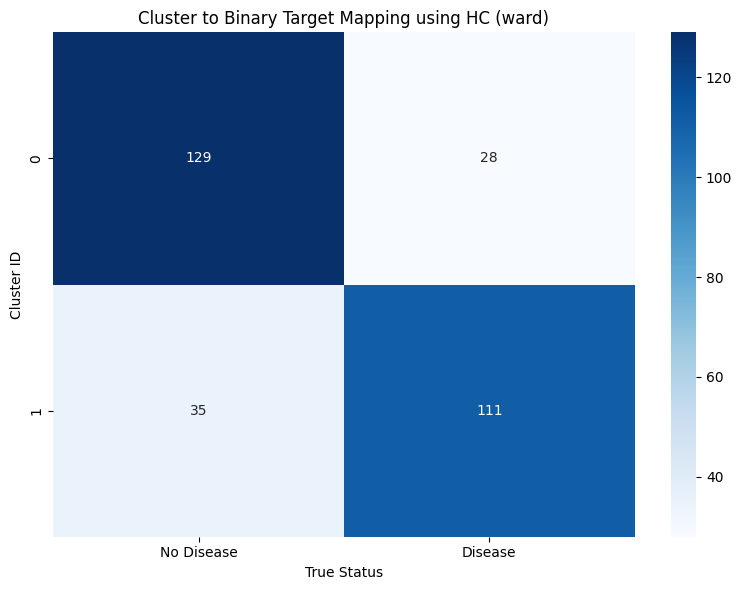

In [ ]:
# fcluster returns labels 1 and 2. We map them to 0 and 1.
# We test both possible mappings to see which aligns best with ground truth.
map_A = {1: 0, 2: 1}
map_B = {1: 1, 2: 0}

preds_A = pd.Series(clusters_hc).map(map_A).values # We assumed that the cluster 1 is healthy and cluster 2 is unhealthy
preds_B = pd.Series(clusters_hc).map(map_B).values # We asumed the opposite

# Check which mapping gives the highest overlap (accuracy) with the truth
acc_A = np.mean(preds_A == y_true_binary)
acc_B = np.mean(preds_B == y_true_binary)

# Select the aligned predictions
preds_hc_aligned = preds_A if acc_A >= acc_B else preds_B

# Compute Metrics using your custom function
sens, spec, f1, ari = compute_metrics(y_true_binary, preds_hc_aligned)

hc_result = [{
    "Method": f"Hierarchical ({final_linkage})",
    "Dataset": "X_final_df",
    "Sensitivity": sens,
    "Specificity": spec,
    "F1": f1,
    "ARI": ari
}]

print("\n--- Evaluation Metrics ---")
display(pd.DataFrame(hc_result))

# Plot Confusion Matrix using your custom function
plot_confusion_matrix(y_pred=preds_hc_aligned, y_true=y_true_binary, method=f"HC ({final_linkage})")

In this case, the sensitivity value is not so good. This means that the model struggles to detect unhealthy patients. However, the healthy patients are better detected. However, in this model we did not get an enhancement of the ARI either.


Once we have seen the metrics, we will analyze the clusters done by the HC model. We will obtain the values of the features represented by each cluster and transformed to the original units to study their patterns.

In [ ]:
# Cluster centers
hc_centers_scaled = X_final_df.copy()
hc_centers_scaled["cluster"] = clusters_hc
hc_centers_scaled = hc_centers_scaled.groupby("cluster").mean()
hc_centers_original = hc_centers_scaled.copy()
for i, col in enumerate(selected_features):
    hc_centers_original[col] = hc_centers_original[col] * scaler.scale_[i] + scaler.mean_[i]
print("Cluster centers:")
display(hc_centers_original.T.round(3))
# Highest and lowest features per cluster
for cluster_id, row in hc_centers_original.iterrows():
    highest = row.sort_values(ascending=False).head(3)
    lowest = row.sort_values(ascending=True).head(3)

    print(f"Cluster {cluster_id}")
    print("  Highest features:")
    for feature, value in highest.items():
        print(f"    - {feature}: {value:.3f}")

    print("  Lowest features:")
    for feature, value in lowest.items():
        print(f"    - {feature}: {value:.3f}")
print(" ")
print("Cluster sizes:")
print(pd.Series(clusters_hc).value_counts().sort_index())

Cluster centers:


cluster,1,2
chol,246.357,247.055
thalach,158.134,140.438
exang,0.153,0.514
oldpeak,0.555,1.560
ca,0.350,1.000
cp_4.0,0.268,0.699
thal_3.0,0.994,0.082
thal_7.0,0.006,0.795


Cluster 1
  Highest features:
    - chol: 246.357
    - thalach: 158.134
    - thal_3.0: 0.994
  Lowest features:
    - thal_7.0: 0.006
    - exang: 0.153
    - cp_4.0: 0.268
Cluster 2
  Highest features:
    - chol: 247.055
    - thalach: 140.438
    - oldpeak: 1.560
  Lowest features:
    - thal_3.0: 0.082
    - exang: 0.514
    - cp_4.0: 0.699
 
Cluster sizes:
1    157
2    146
Name: count, dtype: int64


Here, we can see the trend followed by the other models too. While the healthy patients do not have thal_7 but normal, as well as lower values of slope_2, cp_4, ca and exang. However, the unhealthy patients follow being men over women as well as lower heart beats during exercise.

Finally, having advantages of the use of a hierarchical clustering method we will use the function `clustermap()` from the `seaborn` library to show in graphical way how it is working this model.

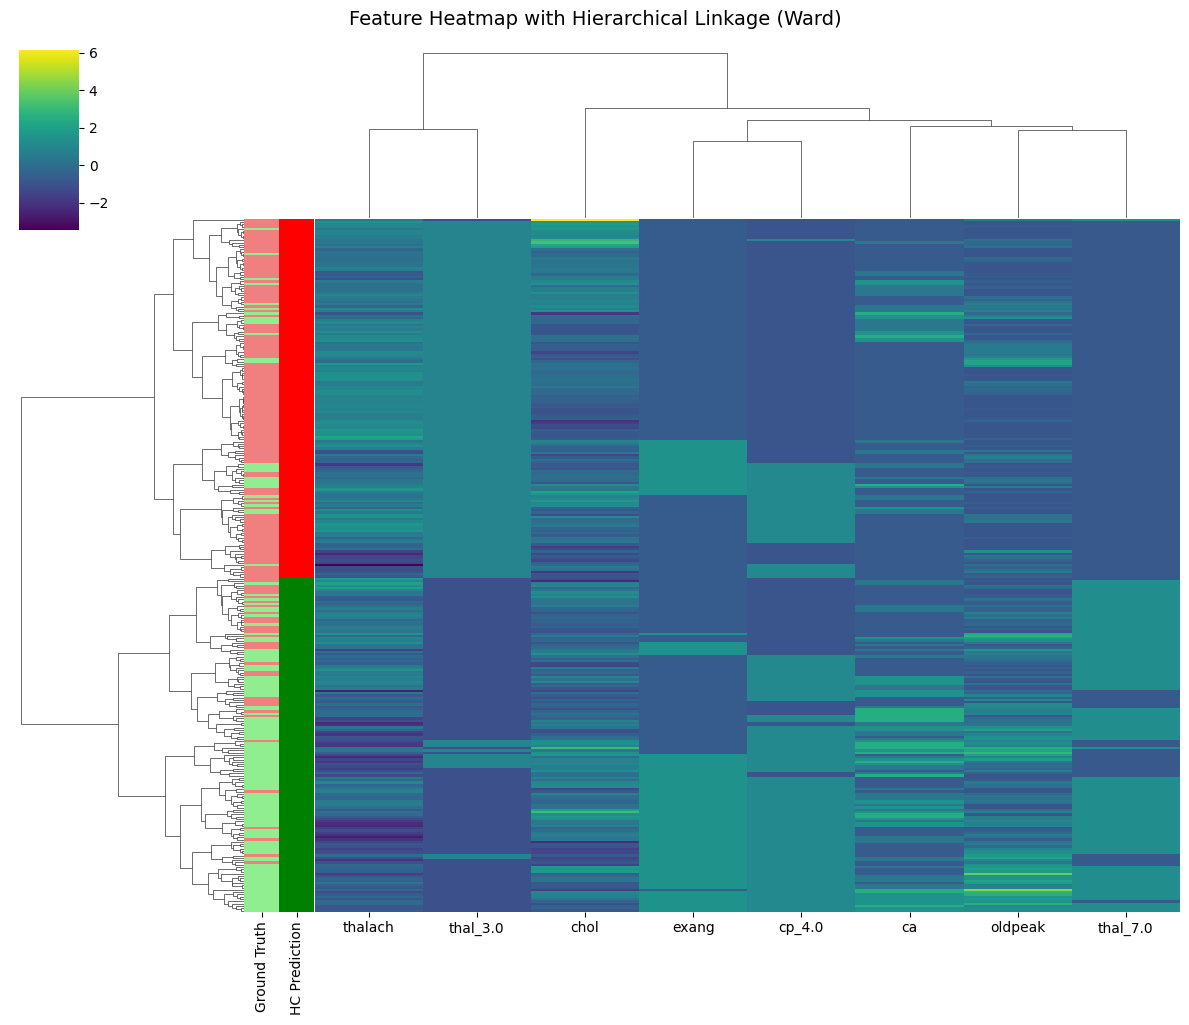

In [ ]:
# Map binary labels to colors for visual comparison
# Adjust the 0 and 1 mapping based on which is Healthy/Unhealthy in your dataset
true_colors = pd.Series(y_true_binary.values).map({0: 'lightcoral', 1: 'lightgreen'})
pred_colors = pd.Series(preds_hc_aligned).map({0: 'red', 1: 'green'})

# Combine into a DataFrame for the seaborn row_colors argument
row_colors_df = pd.DataFrame({
    'Ground Truth': true_colors,
    'HC Prediction': pred_colors
})

# Generate the clustermap
g = sns.clustermap(
    X_final_df,
    method=final_linkage,
    cmap='viridis', # Use a good divergent colormap
    row_colors=row_colors_df,
    figsize=(12, 10),
    yticklabels=False,
    xticklabels=True
)

g.fig.suptitle(f'Feature Heatmap with Hierarchical Linkage ({final_linkage.capitalize()})', y=1.02, fontsize=14)
plt.show()

This graph is very intuitive and we will explain what it is each part.

Firstly, we have a huge matrix created by the **features** of our dataset. In this matrix, we are representing all the instances and their values. These values are shown by color depending of the magnitude of the value they have. For example, we can see as the features: `sex`, `exang` or `cp_4` have 2 intensities of color, that is because they are categorical/binary features.

Secondly, it represents the **ground truth** and the **HC prediction** as green or red for each instance. We can see as the ward linkage has done 2 large divisions: one for collecting the major number of healthy patients, and other for the number of unhealthy patients. Although, we can see a certain overlapped between classes.

Finally, this graph represents clearly the structure of our HC model.

## Comparison between models

Until now, we compared the models individually. Now, we will compare between them. For this reason, we will show the metrics for each one, as well as their confusion matrices.

In [ ]:
all_results = kmean_result + gmm_result + hc_result
final_results = pd.DataFrame(all_results)

final_results.set_index("Method", inplace=True)
final_results


,Dataset,Sensitivity,Specificity,F1,ARI
Method,,,,,
KMeans,X_final_df,0.805755,0.853659,0.814545,0.438187
GMM,X_final_df,0.726619,0.792683,0.737226,0.272944
Hierarchical (ward),X_final_df,0.798561,0.786585,0.778947,0.339064


KMeans clearly outperforms the other methods, achieving superior results across all metrics. Comparing the remaining methods, GMM emerges as the second-best, despite having lower specificity than HC. This is because GMM demonstrates higher sensitivity, f1-score, and Adjusted Rand Index (ARI) compared to HC.


Now, we will show in the same figure the three different confusion matrix for each model to see better the differences.


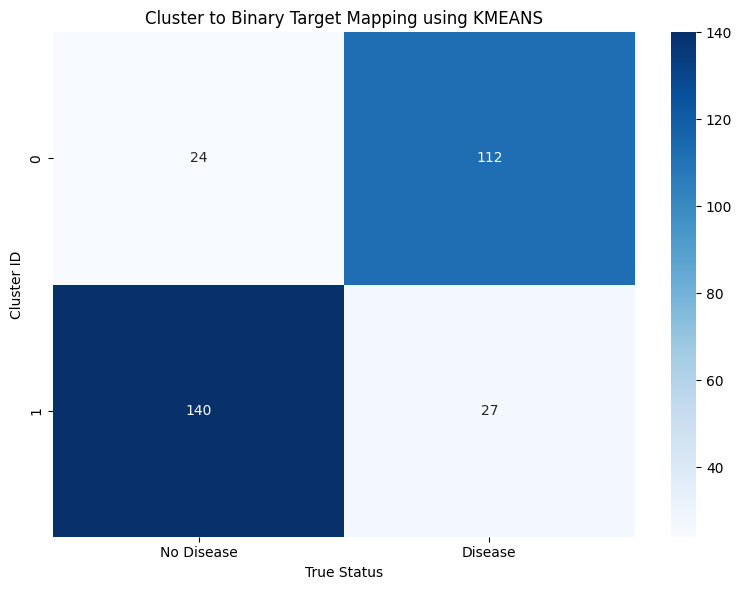

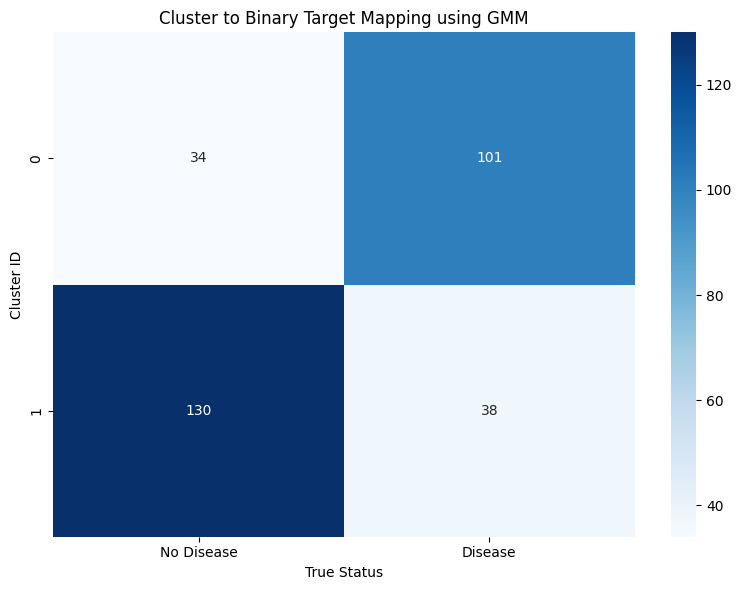

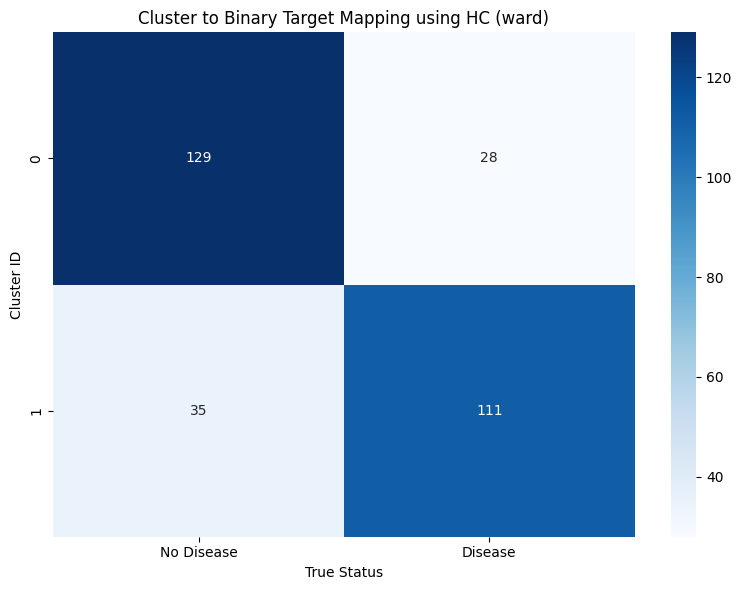

In [ ]:
plot_confusion_matrix(y_pred=preds_knn, y_true=y_true_binary, method="KMEANS")
plot_confusion_matrix(y_pred=preds_gmm, y_true=y_true_binary, method="GMM")
plot_confusion_matrix(y_pred=preds_hc_aligned, y_true=y_true_binary, method=f"HC ({final_linkage})")


Looking at the confusion matrices we can observe some interesting patterns.

The HC is able to capture more healthy patients than the other methods. However, it is the worst in capturing the unhealthy patients, misleading them with healthy patients (FN), something not very good in medicine.

However, as we have seen in the metrics as the K-Means is the king, it is in this matrix so it is the method with the least number of FN and FP.


Also, taking advantages of that ARI is an unsupervised metric we will suppose that we don't have the ground truth and we will use to measure how related are the predictions between the different models.

In [ ]:
preds = [preds_knn, preds_gmm, preds_hc_aligned]
names = ["k-Means", "GMM", "Hierarchical"]

# Initialize an empty square matrix
n = len(preds)
ari_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        # We calculate for all pairs (diagonal will be 1.0)
        ari_matrix[i, j] = adjusted_rand_score(preds[i], preds[j])


df_ari = pd.DataFrame(ari_matrix, index=names, columns=names)
df_ari





,k-Means,GMM,Hierarchical
k-Means,1.000000,0.631389,0.752588
GMM,0.631389,1.000000,0.835205
Hierarchical,0.752588,0.835205,1.000000


We measure the degree of consensus between the three models, treating their respective cluster assignments as labels to compare in the absence of ground truth (unsupervised learning). The highest level of agreement occurs between **k-Means and GMM (0.835)**, suggesting that these two algorithms are identifying very similar boundaries and patterns within the feature space. While the agreement between **k-Means and Hierarchical clustering is the lowest in the set (0.696)**, it still represents a substantial correlation. Overall, the fact that all ARI values are significantly high (above 0.69) indicates that the three methods are able to understand a similar pattern in the data and thus, they are very related. However, if we are guided by the metrics shown, we will have to choose the KMeans method.